# Comment la friction de surface est-elle communiquée à toute la troposphère&nbsp;?


## §0 — Setup commun (identique au pipeline `large300`)



In [1]:
 #============================================================
#  SETUP COMMUN — pipeline large300 (RCEMIP Meso-NH)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import xarray as xr
import gc, os
from scipy.signal import detrend, hilbert
from scipy.ndimage import uniform_filter1d

plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.grid':True,
                     'grid.alpha':0.25,'image.cmap':'RdBu_r'})
Rd,Rv=287.05,461.5; EPSILON=Rd/Rv; g=9.81; KARMAN=0.4
Z_TOP_KM=15.0
DIR_3D,DIR_2D,DIR_1D='3D','2D','1D'
def path3d(v): return os.path.join(DIR_3D,f'MESONH_RCE_large300_3D_{v}.nc')
def path2d(v): return os.path.join(DIR_2D,f'MESONH_RCE_large300_2D_{v}.nc')
def path1d(v): return os.path.join(DIR_1D,f'MESONH_RCE_large300_1D_{v}.nc')
BLOC=2

_ds=xr.open_dataset(path3d('ua')); _da=_ds['ua']
dim_t,dim_z,dim_y,dim_x=_da.dims[:4]
n_t,n_z=_da.sizes[dim_t],_da.sizes[dim_z]; n_y,n_x=_da.sizes[dim_y],_da.sizes[dim_x]
_xv=_da[dim_x].values; dx=float(np.mean(np.diff(_xv))) if _xv.size>1 else 1000.0
if abs(dx)<=1.5: dx=1000.0
_ds.close(); del _ds,_da; gc.collect()
_ds1=xr.open_dataset(path1d('ua_avg')); alt=_ds1.altitude.values.astype(float).copy(); _ds1.close()
x=np.arange(n_x,dtype=float)*dx; zkm=alt/1000.0
mask_show=alt<=Z_TOP_KM*1000; m28=(alt>=2000)&(alt<=8000)

# fenetre stationnaire = toute la fenetre (RCE quasi-stationnaire, cf. runs precedents)
t_stat=0; idx_stat=slice(t_stat,None); n_stat=n_t-t_stat
dt_phys=6*3600.0                      # RCEMIP : snapshots 3D 6-horaires

# masques humide/sec (PRW)
ds_prw=xr.open_dataset(path2d('prw')); prw_all=ds_prw['prw'].load(); ds_prw.close()
prw_mean=prw_all.isel({dim_t:idx_stat}).mean(dim=dim_t)
PRW_SEUIL=float(np.median(prw_all.values.ravel()))
mh=(prw_mean.values>PRW_SEUIL); ms=~mh; del prw_all; gc.collect()

print(f'{n_t} t x {n_z} z x {n_y} y x {n_x} x | dx={dx:.0f}m | dt={dt_phys/3600:.0f}h')
print(f'altitude {alt[0]:.0f}-{alt[-1]:.0f}m | z[1]={alt[1]:.0f}m | fenetre {n_stat} pas = {n_stat*dt_phys/86400:.0f} j')
print(f'humide {mh.mean()*100:.0f}% / sec {ms.mean()*100:.0f}% (seuil PRW={PRW_SEUIL:.1f})')


100 t x 74 z x 128 y x 2000 x | dx=1000m | dt=6h
altitude 0-32500m | z[1]=37m | fenetre 100 pas = 25 j
humide 43% / sec 57% (seuil PRW=30.4)


In [2]:
 #============================================================
#  CHAMPS DE BASE : rho0(z), profils ET champs (z,t)
#   - profils moyens : flux_tot, ubar, dudz, uw       (1D, pour §1-§5-§6)
#   - champs (z,t)   : flux_zt, ubar_zt, wbar_zt, ...  (2D, pour le contexte)
# ============================================================
# rho0(z)
rho0_sum=np.zeros(n_z); n_rho=0
ds_ta=xr.open_dataset(path3d('ta')); ds_pa=xr.open_dataset(path3d('pa')); ds_hus=xr.open_dataset(path3d('hus'))
for t0 in range(t_stat,n_t,BLOC):
    t1=min(t0+BLOC,n_t); sl={dim_t:slice(t0,t1)}
    T=ds_ta['ta'].isel(sl).values; p=ds_pa['pa'].isel(sl).values; qv=ds_hus['hus'].isel(sl).values
    Tv=T*(1+qv/EPSILON)/(1+qv); rho=p/(Rd*Tv)
    rho0_sum+=rho.mean(axis=(0,2,3))*(t1-t0); n_rho+=(t1-t0)
    del T,p,qv,Tv,rho; gc.collect()
ds_ta.close(); ds_pa.close(); ds_hus.close(); rho0=rho0_sum/n_rho

# champs (z,t) : flux, ubar, wbar   (niveau par niveau)
flux_zt=np.zeros((n_z,n_stat)); ubar_zt=np.zeros((n_z,n_stat)); wbar_zt=np.zeros((n_z,n_stat))
ds_u=xr.open_dataset(path3d('ua')); ds_w=xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u=ds_u['ua'].isel({dim_t:idx_stat,dim_z:iz}).values
    w=ds_w['wa'].isel({dim_t:idx_stat,dim_z:iz}).values
    ub=u.mean(axis=(1,2)); wb=w.mean(axis=(1,2))
    up=u-ub[:,None,None]; wp=w-wb[:,None,None]
    flux_zt[iz]=rho0[iz]*(up*wp).mean(axis=(1,2)); ubar_zt[iz]=ub; wbar_zt[iz]=wb
    del u,w,up,wp; gc.collect()
ds_u.close(); ds_w.close(); gc.collect()

# profils moyens (moyenne temporelle des champs zt)
flux_tot=flux_zt.mean(1); ubar=ubar_zt.mean(1); wbar=wbar_zt.mean(1)
uw=flux_tot/rho0; dudz=np.gradient(ubar,alt); d2udz2=np.gradient(dudz,alt)
# derivees des champs zt (pour le contexte dynamique)
dudz_zt=np.gradient(ubar_zt,alt,axis=0); d2udz2_zt=np.gradient(dudz_zt,alt,axis=0)
uw_zt=flux_zt/rho0[:,None]
print(f'rho0 surface={rho0[0]:.3f} | ~10km={rho0[np.argmin(np.abs(alt-10000))]:.3f} kg/m3')
print('profils (flux_tot,ubar,dudz,uw) et champs (flux_zt,ubar_zt,...) prets.')


rho0 surface=1.183 | ~10km=0.410 kg/m3
profils (flux_tot,ubar,dudz,uw) et champs (flux_zt,ubar_zt,...) prets.


In [3]:
# --- Vérification des objets hérités du pipeline (setup notebook 8) ---
import numpy as np, matplotlib.pyplot as plt, gc
from numpy.linalg import lstsq

_required = ['rho0','alt','flux_zt','ubar_zt','wbar_zt','mh','ms',
             'dt_phys','n_stat','n_z','dim_t','dim_z','idx_stat']
_g = globals()
_missing = [k for k in _required if k not in _g]
assert not _missing, f"Objets manquants -> relance le setup large300 : {_missing}"

zkm   = alt/1000.0
Z_LO, Z_HI = 2000.0, 18000.0                 # fenêtre d'étude (2-18 km, comme la régression synthèse)
band  = (alt>=Z_LO)&(alt<=Z_HI)
iz_band = np.where(band)[0]

# profils moyens temporels (au cas où non définis)
flux_tot = flux_zt.mean(1)
ubar     = ubar_zt.mean(1)
dudz     = np.gradient(ubar, alt)
d2udz2   = np.gradient(dudz, alt)
uw       = flux_tot/rho0

print(f"OK. {n_z} niveaux, fenêtre 2-18 km = {band.sum()} niveaux, {n_stat} pas de temps.")
print(f"flux_tot min={flux_tot.min():.2e} @ {alt[np.argmin(flux_tot)]:.0f} m")


OK. 74 niveaux, fenêtre 2-18 km = 33 niveaux, 100 pas de temps.
flux_tot min=-1.17e-02 @ 4500 m


---
## §0bis — Décomposition du bilan de QdM par région (humide $A_c$ / sèche $A_s$)

On part du bilan stationnaire (valide pour $z\gtrsim 2$ km) et on scinde l'intégrale de domaine en sous-domaines humide et sec, chacun décomposé par rapport à **sa propre moyenne conditionnelle** :

$$\rho_0\,\partial_t\bar u + \frac1A\Big[\int_{A_c}\nabla\!\cdot(\rho_0\vec u\vec u) + \int_{A_s}\nabla\!\cdot(\rho_0\vec u\vec u)\Big]\approx 0,\qquad \vec u = \bar{\vec u}_c+\vec u_c'\ (\text{hum}),\ \ \bar{\vec u}_s+\vec u_s'\ (\text{sec}).$$

Appliquée au flux vertical, la **loi de la variance totale** donne une identité exacte :

$$\underbrace{\rho_0\overline{u'w'}}_{\text{global}}=\underbrace{f_c(\bar u_c-\bar u)(\bar w_c-\bar w)+f_s(\bar u_s-\bar u)(\bar w_s-\bar w)}_{\text{CONTRASTE inter-régions (grande échelle)}}+\underbrace{f_c\langle u'w'\rangle_c+f_s\langle u'w'\rangle_s}_{\text{turbulence INTERNE aux régions}}$$

**Question** (ta note manuscrite) : les vents conditionnels $\bar u_c,\bar u_s$ ressemblent-ils au $\bar u$ global&nbsp;? Si oui, le contraste inter-régions transporte peu et tout est interne.

fraction humide fh=0.43 / sèche fs=0.57
contrôle identité |(org+int) - global|_max = 2.01e-08  (doit être ~0)
part médiane du CONTRASTE inter-régions dans |flux| (2-18 km) : 1%
=> le reste (~99%) est de la turbulence INTERNE aux régions.


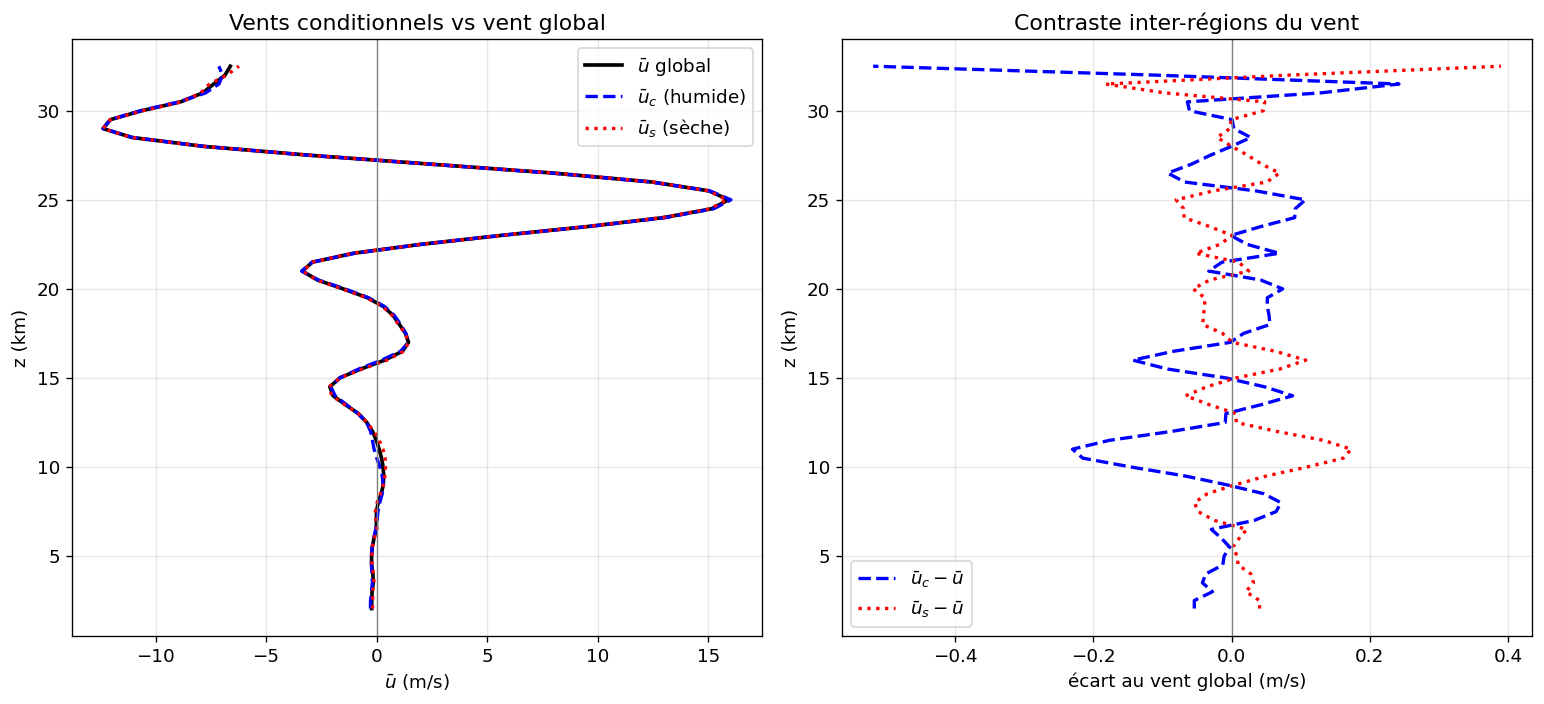

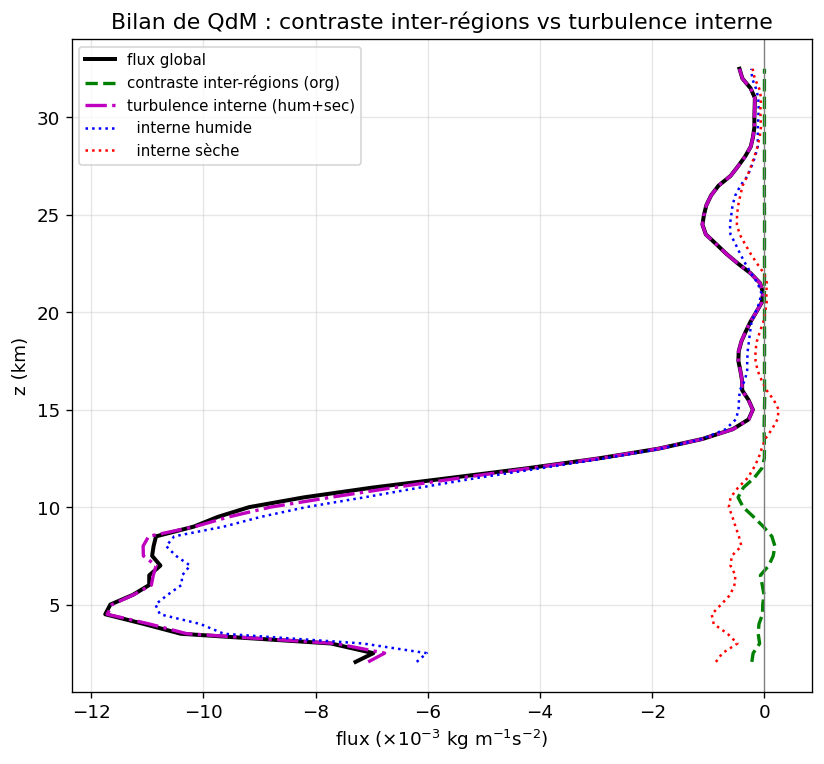


Lecture :
 - Si u_c et u_s collent à <u> => contraste faible => transport surtout INTERNE aux régions.
 - Si u_c et u_s divergent     => le transport a une vraie composante GRANDE ÉCHELLE
   (circulation humide/sèche organisée) qu'une paramétrisation de domaine ignore.


In [4]:
# ============================================================
#  §0bis — DÉCOMPOSITION DU BILAN DE QdM PAR RÉGION (humide Ac / sèche As)
#  Idée (photo) : partir de   rho0 dt<u> + (1/A) ∮ ∇·(rho0 u u) ≈ 0   (z >~ 2 km)
#  et scinder l'intégrale de domaine en deux sous-domaines :
#
#     rho0 dt<u> + (1/A)[ ∫_Ac ∇·(rho0 u u) + ∫_As ∇·(rho0 u u) ] ≈ 0
#
#  Dans CHAQUE région, on décompose le vent par rapport à SA PROPRE moyenne
#  conditionnelle (et non la moyenne globale) :
#       région humide :  u = u_c + u_c'      (u_c = <u>_humide)
#       région sèche  :  u = u_s + u_s'      (u_s = <u>_seche)
#
#  Objectif : (1) plotter u_c, u_s vs u_global pour voir s'ils ressemblent
#             à <u> ou pas  -> mesure du CONTRASTE INTER-RÉGIONS ;
#             (2) isoler, dans le flux vertical de QdM, la part "grande échelle"
#             (contraste des moyennes conditionnelles) de la part "turbulence
#             interne" à chaque région.
#  Tout est calculé niveau par niveau (RAM), fenêtre stationnaire idx_stat.
# ============================================================
import numpy as np, matplotlib.pyplot as plt, gc, xarray as xr

fh = mh.mean()          # fraction d'aire humide
fs = ms.mean()          # fraction d'aire sèche
zkm = alt/1000.0
band2 = alt >= 2000.0   # domaine de validité du bilan (photo : z >~ 2 km)

# --- profils conditionnels : u_c(z), u_s(z), et flux décomposé -----------
u_glob  = np.zeros(n_z)                       # <u> global (rappel)
u_c     = np.zeros(n_z)                       # <u>_humide
u_s     = np.zeros(n_z)                       # <u>_seche
w_c     = np.zeros(n_z); w_s = np.zeros(n_z)  # <w> conditionnels

flux_glob = np.zeros(n_z)                     # rho0 <u'w'>          (réf)
flux_org  = np.zeros(n_z)                     # part CONTRASTE inter-régions (grande échelle)
flux_int  = np.zeros(n_z)                     # part TURBULENCE interne (humide+sèche)
flux_ch   = np.zeros(n_z); flux_cs = np.zeros(n_z)  # interne humide / interne sèche

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u = ds_u['ua'].isel({dim_t: idx_stat, dim_z: iz}).values   # (n_stat, ny, nx)
    w = ds_w['wa'].isel({dim_t: idx_stat, dim_z: iz}).values

    # moyennes globales (sur tout le domaine + temps)
    ub = u.mean(); wb = w.mean()
    u_glob[iz] = ub

    # moyennes CONDITIONNELLES (masques 2D appliqués sur chaque snapshot)
    uc = u[:, mh].mean(); wc = w[:, mh].mean()   # humide
    us = u[:, ms].mean(); ws = w[:, ms].mean()   # sèche
    u_c[iz], w_c[iz] = uc, wc
    u_s[iz], w_s[iz] = us, ws

    # --- flux global (réf) : anomalies vs moyenne GLOBALE ---
    up = u - ub; wp = w - wb
    flux_glob[iz] = rho0[iz] * (up*wp).mean()

    # --- décomposition "loi de la variance totale" ---
    # flux_glob = [ fh*(uc-ub)(wc-wb) + fs*(us-ub)(ws-wb) ]        <- CONTRASTE (org)
    #           + [ fh*<u'w'>_hum      + fs*<u'w'>_sec     ]        <- INTERNE
    org = fh*(uc-ub)*(wc-wb) + fs*(us-ub)*(ws-wb)
    uph = u[:, mh] - uc; wph = w[:, mh] - wc     # fluct. internes humides
    ups = u[:, ms] - us; wps = w[:, ms] - ws     # fluct. internes sèches
    ch  = (uph*wph).mean();  cs = (ups*wps).mean()
    flux_ch[iz] = rho0[iz]*fh*ch
    flux_cs[iz] = rho0[iz]*fs*cs
    flux_org[iz] = rho0[iz]*org
    flux_int[iz] = flux_ch[iz] + flux_cs[iz]

    del u, w, up, wp, uph, wph, ups, wps; gc.collect()
ds_u.close(); ds_w.close(); gc.collect()

# --- contrôle d'identité : org + int == flux global ? -------------------
resid = np.abs((flux_org+flux_int) - flux_glob).max()
print(f"fraction humide fh={fh:.2f} / sèche fs={fs:.2f}")
print(f"contrôle identité |(org+int) - global|_max = {resid:.2e}  (doit être ~0)")

# part relative du contraste inter-régions dans le flux (médiane 2-18 km)
b = band2 & (alt<=18000)
share_org = np.nanmedian(np.abs(flux_org[b])/(np.abs(flux_glob[b])+1e-30))*100
print(f"part médiane du CONTRASTE inter-régions dans |flux| (2-18 km) : {share_org:.0f}%")
print(f"=> le reste (~{100-share_org:.0f}%) est de la turbulence INTERNE aux régions.")

# ============================================================
#  FIGURE 1 : u_c, u_s ressemblent-ils à <u> ?  (la question de la photo)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax = axes[0]
ax.plot(u_glob[band2], zkm[band2], 'k-',  lw=2.2, label=r'$\bar u$ global')
ax.plot(u_c[band2],    zkm[band2], 'b--', lw=2,   label=r'$\bar u_c$ (humide)')
ax.plot(u_s[band2],    zkm[band2], 'r:',  lw=2,   label=r'$\bar u_s$ (sèche)')
ax.axvline(0, color='grey', lw=.8)
ax.set_xlabel(r'$\bar u$ (m/s)'); ax.set_ylabel('z (km)')
ax.set_title('Vents conditionnels vs vent global')
ax.legend(); ax.grid(alpha=.3)

# écart des vents conditionnels au vent global (le "contraste")
ax = axes[1]
ax.plot((u_c-u_glob)[band2], zkm[band2], 'b--', lw=2, label=r'$\bar u_c-\bar u$')
ax.plot((u_s-u_glob)[band2], zkm[band2], 'r:',  lw=2, label=r'$\bar u_s-\bar u$')
ax.axvline(0, color='grey', lw=.8)
ax.set_xlabel(r'écart au vent global (m/s)'); ax.set_ylabel('z (km)')
ax.set_title('Contraste inter-régions du vent')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

# ============================================================
#  FIGURE 2 : décomposition du flux  global = contraste + interne
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.plot(flux_glob[band2]*1e3, zkm[band2], 'k-',  lw=2.4, label='flux global')
ax.plot(flux_org[band2] *1e3, zkm[band2], 'g--', lw=2,   label='contraste inter-régions (org)')
ax.plot(flux_int[band2] *1e3, zkm[band2], 'm-.', lw=2,   label='turbulence interne (hum+sec)')
ax.plot(flux_ch[band2]  *1e3, zkm[band2], 'b:',  lw=1.5, label='  interne humide')
ax.plot(flux_cs[band2]  *1e3, zkm[band2], 'r:',  lw=1.5, label='  interne sèche')
ax.axvline(0, color='grey', lw=.8)
ax.set_xlabel(r"flux ($\times10^{-3}$ kg m$^{-1}$s$^{-2}$)"); ax.set_ylabel('z (km)')
ax.set_title('Bilan de QdM : contraste inter-régions vs turbulence interne')
ax.legend(fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("\nLecture :")
print(" - Si u_c et u_s collent à <u> => contraste faible => transport surtout INTERNE aux régions.")
print(" - Si u_c et u_s divergent     => le transport a une vraie composante GRANDE ÉCHELLE")
print("   (circulation humide/sèche organisée) qu'une paramétrisation de domaine ignore.")

### §0bis — Lecture du résultat

Le contrôle d'identité se ferme au zéro machine ($\sim2\times10^{-8}$), et la mesure clé est nette :
**le contraste inter-régions ne porte qu'environ 1 % du flux** ; les vents conditionnels $\bar u_c$ et $\bar u_s$ sont quasi superposés au $\bar u$ global (écarts $<0.5$ m/s). 

**C'est un vrai résultat, pas un échec** : dans `large300`, la friction n'est **pas** communiquée par une circulation de grande échelle entre colonnes humides et sèches (le contraste de vent moyen entre régions est négligeable). La quasi-totalité du transport est **interne** — porté par la turbulence convective *à l'intérieur* de chaque région. Cela justifie de se concentrer sur la structure verticale du transport turbulent (§1–§4), et non sur une paramétrisation du contraste humide/sec.

In [5]:
# ============================================================
#  §0bis (v3.1) — BILAN DE QdM PAR SOUS-DOMAINE, TERME PAR TERME
#
#    rho0 dt<u> + (1/A)[ int_Ac div(rho0 u u) + int_As div(rho0 u u) ] = RES
#
#  Sur un SOUS-domaine, div n'est pas reductible a d/dz :
#     (1/A) int_AR div(rho0 u u) = LAT_R + VERT_R
#     LAT_R  = (1/A) int_AR [ dx(rho0 u u) + dy(rho0 v u) ]   (echange lateral)
#     VERT_R = d/dz [ (1/A) int_AR rho0 w u ]                 (flux vertical)
#  Controle : LAT_c + LAT_s = 0 (periodicite du domaine complet).
#  RES = ce que les champs resolus ne ferment pas = -dz(flux sous-maille).
#
#  v3.1 : - appariement temporel 2D/3D (prw plus frequent que les sorties 3D)
#         - reparation des pas de temps ou une region est VIDE (source des NaN)
#         - sommes en float64 (les controles d'identite l'exigent)
# ============================================================
import numpy as np, xarray as xr, gc

# --- pas de grille horizontaux ----------------------------------------
_ds = xr.open_dataset(path3d('ua'))
_yv = _ds[dim_y].values.astype(float)
dy = float(np.mean(np.diff(_yv))) if _yv.size > 1 else dx
if abs(dy) <= 1.5: dy = dx           # coord. en km ou en indice -> on retombe sur dx
_ds.close(); del _ds, _yv; gc.collect()
print(f"dx={dx:.0f} m   dy={dy:.0f} m")

# --- masque humide dynamique, aligne sur les instants 3D ---------------
MASK_MODE = 'fixed_thresh'   # 'static' | 'fixed_thresh' | 'median_t'
PRW_Q     = 0.50             # quantile du seuil fixe (0.50 = mediane)
F_MIN     = 0.02             # fraction d'aire minimale toleree par region

ds_prw = xr.open_dataset(path2d('prw'))
da_prw = ds_prw['prw']
tdim2 = next((d for d in da_prw.dims if da_prw.sizes[d] not in (n_y, n_x)), da_prw.dims[0])
n_t2  = da_prw.sizes[tdim2]

idx3 = np.arange(n_t)[idx_stat]
if n_t2 == n_t:
    idx2 = idx3
else:
    _d = xr.open_dataset(path3d('ua'))
    t3 = _d[dim_t].values if dim_t in _d.coords else None
    _d.close()
    t2 = da_prw[tdim2].values if tdim2 in da_prw.coords else None
    def _num(a):
        return (a.astype('datetime64[s]').astype(np.float64)
                if np.issubdtype(a.dtype, np.datetime64) else a.astype(np.float64))
    if t3 is not None and t2 is not None and t3.size == n_t and t2.size == n_t2:
        a3, a2 = _num(t3), _num(t2)
        idx2 = np.abs(a2[None, :] - a3[:, None]).argmin(1)[idx_stat]
        print(f"appariement par coordonnee : ecart max {np.abs(a2[idx2]-a3[idx3]).max():.0f}")
    else:
        assert n_t2 % n_t == 0, f"pas de correspondance simple : {n_t2} pas 2D / {n_t} pas 3D"
        r = n_t2 // n_t
        idx2 = ((np.arange(n_t) + 1)*r - 1)[idx_stat]
        print(f"appariement par pas constant : 1 snapshot 2D sur {r}")

prw = da_prw.isel({tdim2: idx2}).values.astype(np.float32)   # (n_stat, ny, nx)
ds_prw.close(); del da_prw
assert prw.shape[0] == n_stat, f"{prw.shape[0]} != n_stat={n_stat}"

if MASK_MODE == 'static':
    maskc = np.broadcast_to(mh, (n_stat,) + mh.shape).copy()
elif MASK_MODE == 'median_t':
    maskc = prw > np.median(prw.reshape(n_stat, -1), axis=1).astype(np.float32)[:, None, None]
else:
    seuil = np.float32(np.quantile(prw, PRW_Q))
    maskc = prw > seuil
    print(f"seuil PRW fixe (q={PRW_Q:.2f}) = {float(seuil):.2f} kg/m2")

# --- REPARATION des pas de temps degeneres (une region vide => NaN) ----
frac = maskc.reshape(n_stat, -1).mean(1)
bad  = np.where((frac < F_MIN) | (frac > 1.0 - F_MIN))[0]
if bad.size:
    print(f"/!\\ {bad.size} pas de temps degeneres (fraction humide hors [{F_MIN},{1-F_MIN}])")
    print(f"    -> seuil recalcule localement a la mediane de l'instant : t={bad[:10]}...")
    for t in bad:
        maskc[t] = prw[t] > np.float32(np.median(prw[t]))
    frac = maskc.reshape(n_stat, -1).mean(1)
del prw; gc.collect()

Mc     = maskc.reshape(n_stat, -1)
Ncell  = Mc.shape[1]
Nc     = Mc.sum(1).astype(np.float64); Ns = Ncell - Nc
assert Nc.min() > 0 and Ns.min() > 0, "region encore vide apres reparation"
fc_t   = Nc/Ncell; fs_t = Ns/Ncell
churn  = float((maskc[1:] != maskc[:-1]).mean())
del maskc; gc.collect()
print(f"fraction humide : moy {fc_t.mean():.3f}  min {fc_t.min():.3f}  max {fc_t.max():.3f}")
print(f"renouvellement du masque entre 2 pas : {churn*100:.1f} % des mailles changent de region")

# --- helpers (sommes en float64 : les controles d'identite en dependent)
def _means(X):
    """moyennes : globale, conditionnelle humide, conditionnelle seche"""
    tot = X.sum(1, dtype=np.float64); sc = (X*Mc).sum(1, dtype=np.float64)
    return tot/Ncell, sc/Nc, (tot-sc)/Ns

def _parts(X):
    """integrales partielles normalisees par A : (1/A)int_Ac , (1/A)int_As"""
    tot = X.sum(1, dtype=np.float64); sc = (X*Mc).sum(1, dtype=np.float64)
    return sc/Ncell, (tot-sc)/Ncell

Z = lambda: np.zeros((n_z, n_stat))
Ug, Uc, Us = Z(), Z(), Z()           # <u>, <u>_c, <u>_s
Wg, Wc, Ws = Z(), Z(), Z()
UWg, UWc, UWs = Z(), Z(), Z()        # <uw> totaux (pas des anomalies)
UUc, UUs, WWc, WWs = Z(), Z(), Z(), Z()
TENc, TENs = Z(), Z()                # (1/A) int_AR rho0 dt u
LATc, LATs = Z(), Z()                # flux lateral a travers l'interface

# --- boucle niveau par niveau -----------------------------------------
ds_u = xr.open_dataset(path3d('ua'))
ds_v = xr.open_dataset(path3d('va'))
ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u = ds_u['ua'].isel({dim_t: idx_stat, dim_z: iz}).values.astype(np.float32)
    v = ds_v['va'].isel({dim_t: idx_stat, dim_z: iz}).values.astype(np.float32)
    w = ds_w['wa'].isel({dim_t: idx_stat, dim_z: iz}).values.astype(np.float32)
    r = np.float32(rho0[iz])

    # ---- LAT : divergence horizontale, differences centrees periodiques
    F = u*u
    divh = (np.roll(F,-1,axis=2) - np.roll(F,1,axis=2))/np.float32(2*dx)
    F = v*u; del v
    divh += (np.roll(F,-1,axis=1) - np.roll(F,1,axis=1))/np.float32(2*dy)
    del F; gc.collect()
    pc, ps = _parts(divh.reshape(n_stat,-1)); LATc[iz] = r*pc; LATs[iz] = r*ps
    del divh; gc.collect()

    # ---- TEND : derivee temporelle ponctuelle, PUIS moyenne masquee
    dudt = np.gradient(u, dt_phys, axis=0)
    pc, ps = _parts(dudt.reshape(n_stat,-1)); TENc[iz] = r*pc; TENs[iz] = r*ps
    del dudt; gc.collect()

    # ---- moments conditionnels
    U = u.reshape(n_stat,-1); W = w.reshape(n_stat,-1); del u, w
    Ug[iz], Uc[iz], Us[iz] = _means(U)
    Wg[iz], Wc[iz], Ws[iz] = _means(W)
    UWg[iz], UWc[iz], UWs[iz] = _means(U*W)
    _, UUc[iz], UUs[iz] = _means(U*U)
    _, WWc[iz], WWs[iz] = _means(W*W)
    del U, W; gc.collect()

ds_u.close(); ds_v.close(); ds_w.close(); gc.collect()

_nan = {k: int(np.isnan(v).sum()) for k, v in
        dict(Uc=Uc, Us=Us, Wc=Wc, Ws=Ws, UWc=UWc, UWs=UWs, LATc=LATc, TENc=TENc).items()}
print("NaN residuels :", _nan if any(_nan.values()) else "aucun")
print("termes bruts calcules.")


dx=1000 m   dy=1000 m
appariement par pas constant : 1 snapshot 2D sur 24
seuil PRW fixe (q=0.50) = 30.26 kg/m2
/!\ 5 pas de temps degeneres (fraction humide hors [0.02,0.98])
    -> seuil recalcule localement a la mediane de l'instant : t=[0 1 2 3 4]...
fraction humide : moy 0.475  min 0.325  max 0.979
renouvellement du masque entre 2 pas : 7.4 % des mailles changent de region
NaN residuels : aucun
termes bruts calcules.


In [6]:
 #============================================================
#  §0bis.B — assemblage des termes, controles exacts, fermeture
# ============================================================
R = rho0[:, None]

# --- flux verticaux resolus, par region --------------------------------
MFc  = R*fc_t*Uc*Wc                        # circulation organisee humide
MFs  = R*fs_t*Us*Ws                        #                       seche
INTc = R*fc_t*(UWc - Uc*Wc)                # turbulence interne humide
INTs = R*fs_t*(UWs - Us*Ws)                #                    seche
PHI  = R*UWg                               # flux vertical total resolu

VERTc = np.gradient(MFc + INTc, alt, axis=0)
VERTs = np.gradient(MFs + INTs, alt, axis=0)

# --- bilan complet -----------------------------------------------------
BUDc = TENc + LATc + VERTc
BUDs = TENs + LATs + VERTs
RES  = BUDc + BUDs                          # = -dz(flux sous-maille)

# --- identites de controle (doivent etre au zero machine) --------------
e1 = np.abs(LATc + LATs).max()/(np.abs(LATc).max() + 1e-30)
e2 = np.abs((MFc+MFs+INTc+INTs) - PHI).max()/(np.abs(PHI).max() + 1e-30)
e3 = np.abs(fc_t*Uc + fs_t*Us - Ug).max()
print(f"[ctrl] LAT_c + LAT_s = 0            : erreur relative {e1:.2e}")
print(f"[ctrl] MF + INT = flux total resolu : erreur relative {e2:.2e}")
print(f"[ctrl] f_c u_c + f_s u_s = u_global : erreur absolue  {e3:.2e} m/s")

# --- decomposition du flux : contraste vs interne, PAR PAS DE TEMPS ----
dUc, dWc = Uc - Ug, Wc - Wg
dUs, dWs = Us - Ug, Ws - Wg
ORG  = R*(fc_t*dUc*dWc + fs_t*dUs*dWs)      # contraste inter-regions
INT  = INTc + INTs                          # turbulence interne
FLXp = R*(UWg - Ug*Wg)                      # rho0 <u'w'> global
print(f"[ctrl] ORG + INT = rho0<u'w'>       : erreur relative "
      f"{np.abs(ORG+INT-FLXp).max()/(np.abs(FLXp).max()+1e-30):.2e}")

# --- ce que la v1 mesurait : la part STATIONNAIRE du contraste ---------
fcm, fsm = fc_t.mean(), fs_t.mean()
ORG_bar  = ORG.mean(1)
ORG_stat = rho0*(fcm*dUc.mean(1)*dWc.mean(1) + fsm*dUs.mean(1)*dWs.mean(1))
ORG_tran = ORG_bar - ORG_stat               # contraste TRANSITOIRE (perdu en v1)

b   = (alt >= 2000) & (alt <= 18000)
den = np.abs(FLXp.mean(1)[b]) + 1e-30
print()
print("Part du flux vertical portee par le contraste inter-regions (mediane 2-18 km) :")
print(f"   contraste total       {np.nanmedian(np.abs(ORG_bar[b])/den)*100:6.1f} %")
print(f"     dont stationnaire   {np.nanmedian(np.abs(ORG_stat[b])/den)*100:6.1f} %   <- v1")
print(f"     dont transitoire    {np.nanmedian(np.abs(ORG_tran[b])/den)*100:6.1f} %   <- recupere ici")
print(f"   turbulence interne    {np.nanmedian(np.abs(INT.mean(1)[b])/den)*100:6.1f} %")

# --- amplitude du terme lateral, que la v1 ignorait totalement ---------
sc_ = np.abs(VERTc + VERTs)[b].mean() + 1e-30
print()
print(f"Amplitude du flux lateral |LAT_c| rapportee au terme vertical : "
      f"{np.abs(LATc)[b].mean()/sc_*100:.1f} %")
print("(LAT_c = -LAT_s : echange net de QdM entre colonne humide et colonne seche)")

# --- residu = flux sous-maille, integre depuis le sommet ---------------
RES_bar = RES.mean(1)
seg     = 0.5*(RES_bar[1:] + RES_bar[:-1])*np.diff(alt)
PHI_sgs = np.concatenate([np.cumsum(seg[::-1])[::-1], [0.0]])
print()
print(f"Contrainte de surface diagnostiquee tau_s = {PHI_sgs[0]:.4f} kg m-1 s-2")
print(f"Flux resolu au 1er niveau            = {PHI.mean(1)[0]:.4f} kg m-1 s-2")
print("(le residu absorbe aussi les erreurs de troncature du schema : ordre de grandeur)")

[ctrl] LAT_c + LAT_s = 0            : erreur relative 2.83e-08
[ctrl] MF + INT = flux total resolu : erreur relative 4.14e-16
[ctrl] f_c u_c + f_s u_s = u_global : erreur absolue  3.55e-15 m/s
[ctrl] ORG + INT = rho0<u'w'>       : erreur relative 2.76e-16

Part du flux vertical portee par le contraste inter-regions (mediane 2-18 km) :
   contraste total          1.5 %
     dont stationnaire      0.7 %   <- v1
     dont transitoire       1.1 %   <- recupere ici
   turbulence interne     100.7 %

Amplitude du flux lateral |LAT_c| rapportee au terme vertical : 139.1 %
(LAT_c = -LAT_s : echange net de QdM entre colonne humide et colonne seche)

Contrainte de surface diagnostiquee tau_s = 0.0005 kg m-1 s-2
Flux resolu au 1er niveau            = 0.0000 kg m-1 s-2
(le residu absorbe aussi les erreurs de troncature du schema : ordre de grandeur)


[ctrl] I_c + I_s = dz(rho0<wu>) : erreur relative 1.23e-08
       (ne teste que LAT_c+LAT_s=0 : les horizontales s'annulent par periodicite)

terme                        RMS_c     RMS_s   |  int_c     int_s
                         (1e-6 SI) (1e-6 SI) | (1e-3 kg/m/s2)
------------------------------------------------------------------
TEN  rho0 dt u               0.141     0.167 |     1.077    -0.140
LAT  echange lateral         0.831     0.831 |    -7.082     7.082
VERT convergence vert.       1.211     0.339 |     6.231     0.795
I    = LAT+VERT              1.376     0.846 |    -0.851     7.877
RES  = TEN+I                 1.375     0.845 |     0.226     7.737

Export lateral net humide->sec sur 2-18 km : -7.082 x1e-3 kg m-1 s-2
a comparer a la contrainte de surface tau_s = +0.514 x1e-3
=> l'echange lateral represente 1378.2 % de tau_s en equivalent contrainte


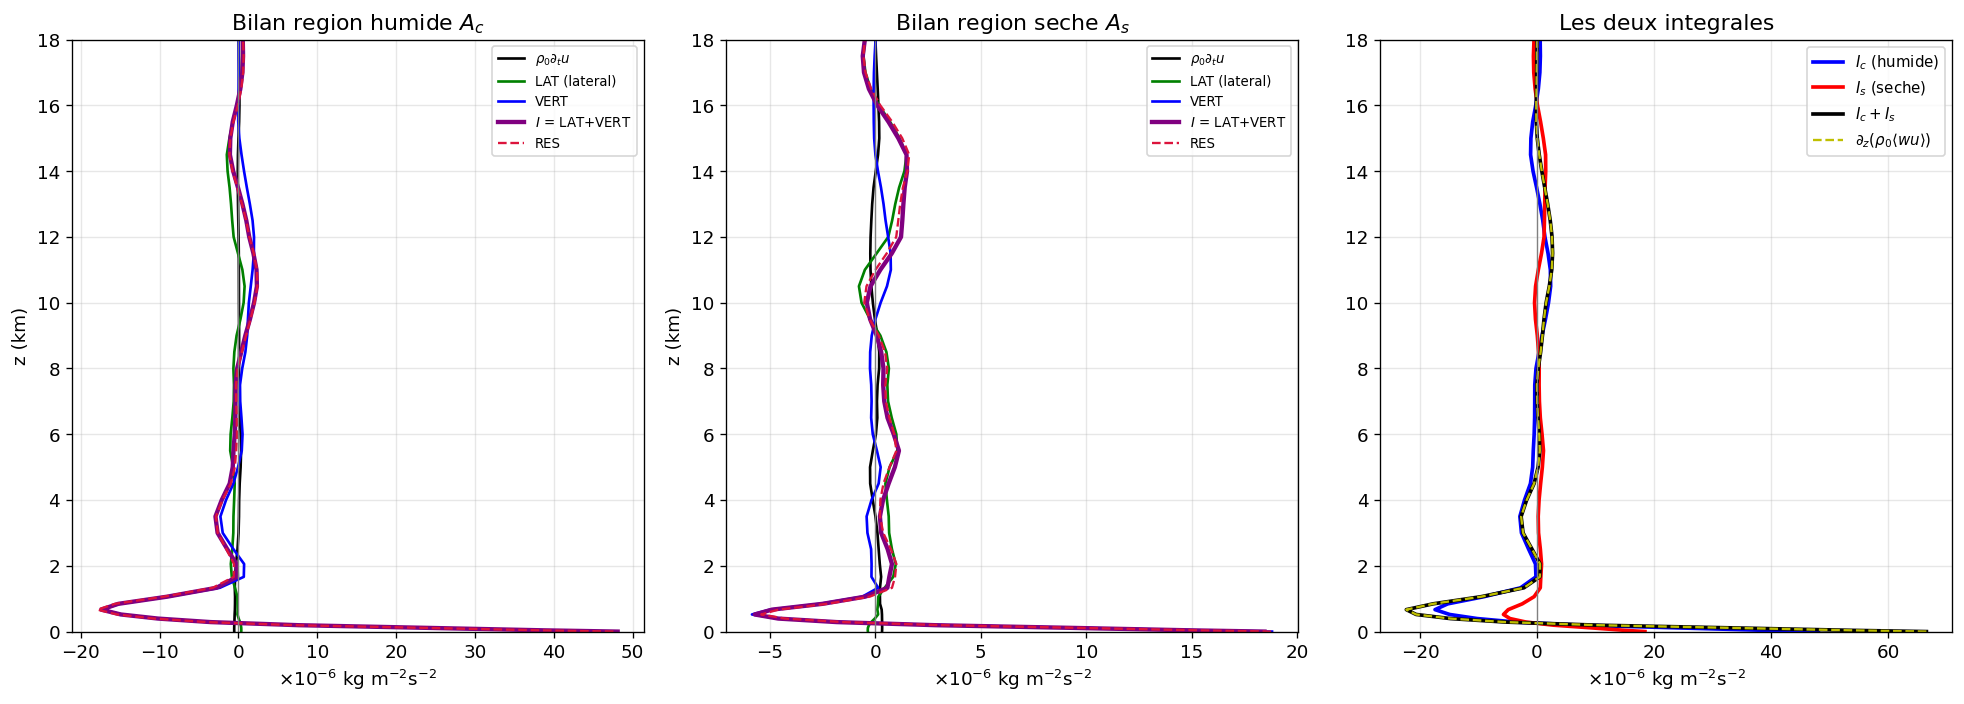

In [7]:
# ============================================================
#  §0bis.D — LES DEUX INTEGRALES, EXPLICITEMENT
#
#     I_c = (1/A) int_Ac div(rho0 u u) dA = LAT_c + VERT_c
#     I_s = (1/A) int_As div(rho0 u u) dA = LAT_s + VERT_s
#
#  Bilan par region :  TEN_R + I_R = RES_R      (RES_R = -sous-maille region R)
#  Bilan global     : (TEN_c+TEN_s) + (I_c+I_s) = RES
#
#  Le masque vient du PRW (colonne) => il ne depend PAS de z, donc
#  d/dz commute avec int_A_R : VERT_R = d/dz[(1/A) int_A_R rho0 w u].
# ============================================================
import numpy as np, matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

SMOOTH = 3          # lissage vertical POUR L'AFFICHAGE seulement (0 = brut)

DIVc = LATc + VERTc                 # <- integrale 1
DIVs = LATs + VERTs                 # <- integrale 2
RESc = TENc + DIVc                  # residu sous-maille, region humide
RESs = TENs + DIVs                  #                     region seche

# --- controle : I_c + I_s = dz(rho0<wu>) -------------------------------
dzPHI = np.gradient(PHI, alt, axis=0)
e4 = np.abs((DIVc+DIVs) - dzPHI).max()/(np.abs(dzPHI).max()+1e-30)
print(f"[ctrl] I_c + I_s = dz(rho0<wu>) : erreur relative {e4:.2e}")
print("       (ne teste que LAT_c+LAT_s=0 : les horizontales s'annulent par periodicite)")

# --- tableau des amplitudes -------------------------------------------
bnd = (alt >= 2000) & (alt <= 18000)
def _col(a):                                    # integrale de colonne, 2-18 km
    aa, zz = a[bnd], alt[bnd]
    return float(np.sum(0.5*(aa[1:]+aa[:-1])*np.diff(zz)))
def _stat(A):
    a = A.mean(1)
    return np.sqrt(np.mean(a[bnd]**2))*1e6, _col(a)*1e3

rows = [('TEN  rho0 dt u', TENc, TENs), ('LAT  echange lateral', LATc, LATs),
        ('VERT convergence vert.', VERTc, VERTs), ('I    = LAT+VERT', DIVc, DIVs),
        ('RES  = TEN+I', RESc, RESs)]
print(f"\n{'terme':24s} {'RMS_c':>9s} {'RMS_s':>9s} {'|  int_c':>10s} {'int_s':>9s}")
print(f"{'':24s} {'(1e-6 SI)':>9s} {'(1e-6 SI)':>9s} {'| (1e-3 kg/m/s2)':>10s}")
print('-'*66)
for nm, Ac_, As_ in rows:
    rc, ic = _stat(Ac_); rs, is_ = _stat(As_)
    print(f"{nm:24s} {rc:9.3f} {rs:9.3f} | {ic:9.3f} {is_:9.3f}")

print(f"\nExport lateral net humide->sec sur 2-18 km : {_col(LATc.mean(1))*1e3:+.3f} "
      f"x1e-3 kg m-1 s-2")
print(f"a comparer a la contrainte de surface tau_s = {PHI_sgs[0]*1e3:+.3f} x1e-3")
print(f"=> l'echange lateral represente {abs(_col(LATc.mean(1))/(PHI_sgs[0]+1e-30))*100:.1f} % "
      f"de tau_s en equivalent contrainte")

# --- figures -----------------------------------------------------------
sm = (lambda a: uniform_filter1d(a, SMOOTH)) if SMOOTH else (lambda a: a)
m  = alt <= 18000
zk = zkm

fig, ax = plt.subplots(1, 3, figsize=(16.5, 6))

for k, (lab, TE, LA, VE, DI, RE) in enumerate([
        ('humide $A_c$', TENc, LATc, VERTc, DIVc, RESc),
        ('seche $A_s$',  TENs, LATs, VERTs, DIVs, RESs)]):
    a = ax[k]
    a.plot(sm(TE.mean(1))[m]*1e6, zk[m], 'k',  lw=1.6, label=r'$\rho_0\partial_t u$')
    a.plot(sm(LA.mean(1))[m]*1e6, zk[m], 'g',  lw=1.6, label='LAT (lateral)')
    a.plot(sm(VE.mean(1))[m]*1e6, zk[m], 'b',  lw=1.6, label='VERT')
    a.plot(sm(DI.mean(1))[m]*1e6, zk[m], 'purple', lw=2.6, label=r'$I$ = LAT+VERT')
    a.plot(sm(RE.mean(1))[m]*1e6, zk[m], 'crimson', lw=1.4, ls='--', label='RES')
    a.axvline(0, color='grey', lw=.8)
    a.set_title(f'Bilan region {lab}'); a.set_xlabel(r'$\times10^{-6}$ kg m$^{-2}$s$^{-2}$')
    a.set_ylabel('z (km)'); a.legend(fontsize=8)

a = ax[2]
a.plot(sm(DIVc.mean(1))[m]*1e6, zk[m], 'b', lw=2.2, label=r'$I_c$ (humide)')
a.plot(sm(DIVs.mean(1))[m]*1e6, zk[m], 'r', lw=2.2, label=r'$I_s$ (seche)')
a.plot(sm((DIVc+DIVs).mean(1))[m]*1e6, zk[m], 'k', lw=2.2, label=r'$I_c+I_s$')
a.plot(sm(dzPHI.mean(1))[m]*1e6, zk[m], 'y--', lw=1.4, label=r'$\partial_z(\rho_0\langle wu\rangle)$')
a.axvline(0, color='grey', lw=.8)
a.set_title('Les deux integrales'); a.set_xlabel(r'$\times10^{-6}$ kg m$^{-2}$s$^{-2}$')
a.legend(fontsize=9)

for a in ax: a.grid(alpha=.3); a.set_ylim(0, 18)
plt.tight_layout(); plt.show()

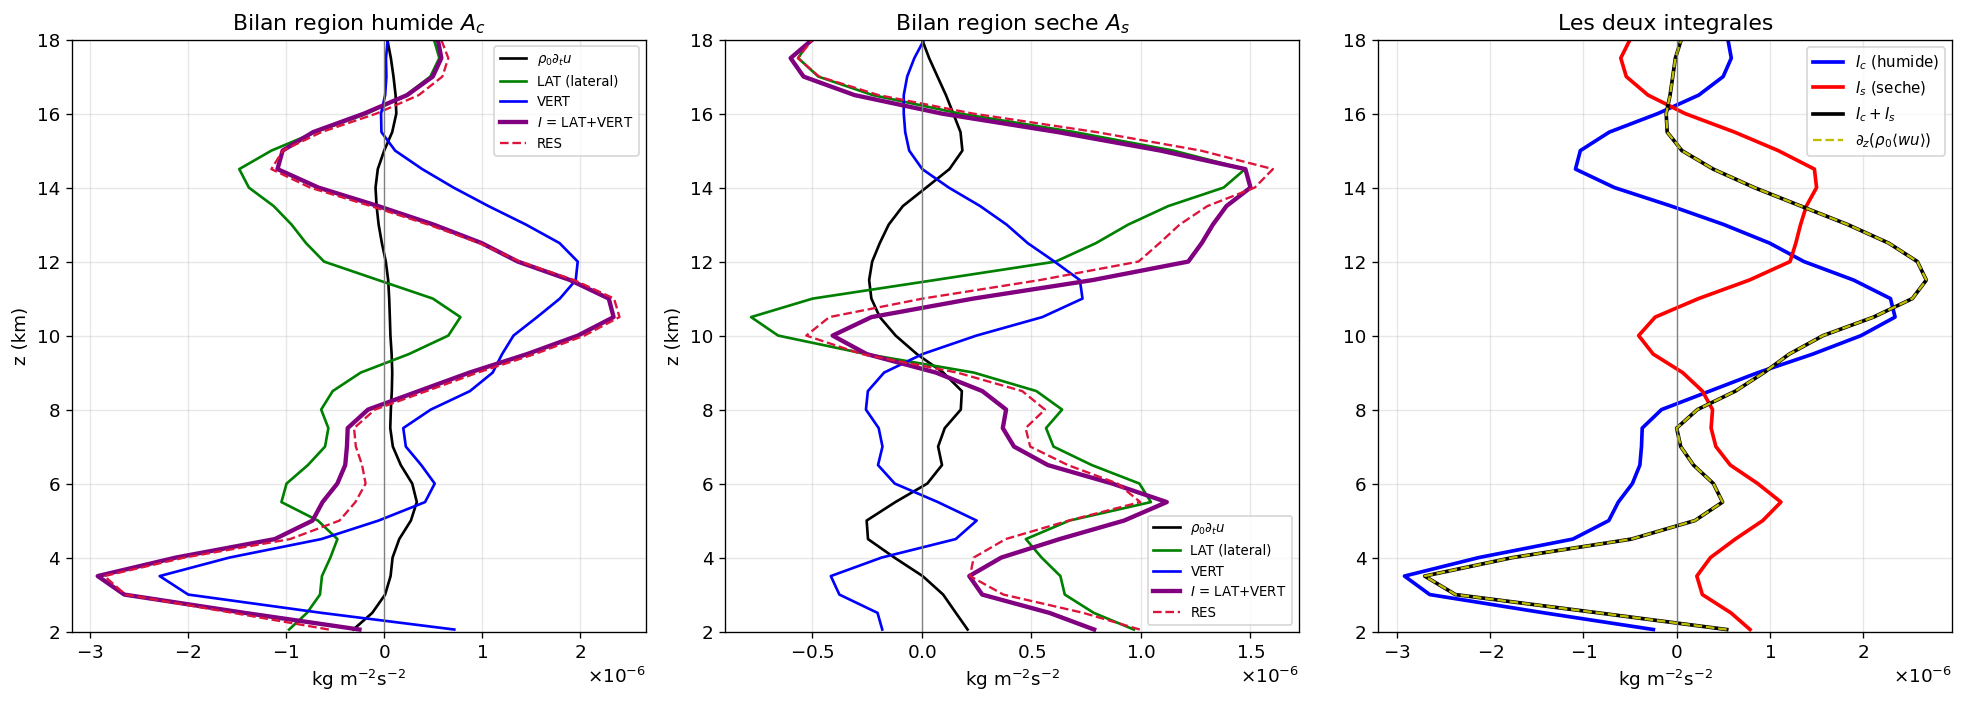

In [8]:
# --- figures (2-18 km) -------------------------------------------------
sm = (lambda a: uniform_filter1d(a, SMOOTH)) if SMOOTH else (lambda a: a)
m  = bnd                      # <- fenetre 2-18 km, coherente avec le tableau
zk = zkm

fig, ax = plt.subplots(1, 3, figsize=(16.5, 6))

for k, (lab, TE, LA, VE, DI, RE) in enumerate([
        ('humide $A_c$', TENc, LATc, VERTc, DIVc, RESc),
        ('seche $A_s$',  TENs, LATs, VERTs, DIVs, RESs)]):
    a = ax[k]
    a.plot(sm(TE.mean(1))[m], zk[m], 'k',  lw=1.6, label=r'$\rho_0\partial_t u$')
    a.plot(sm(LA.mean(1))[m], zk[m], 'g',  lw=1.6, label='LAT (lateral)')
    a.plot(sm(VE.mean(1))[m], zk[m], 'b',  lw=1.6, label='VERT')
    a.plot(sm(DI.mean(1))[m], zk[m], 'purple', lw=2.6, label=r'$I$ = LAT+VERT')
    a.plot(sm(RE.mean(1))[m], zk[m], 'crimson', lw=1.4, ls='--', label='RES')
    a.axvline(0, color='grey', lw=.8)
    a.set_title(f'Bilan region {lab}'); a.set_xlabel(r'kg m$^{-2}$s$^{-2}$')
    a.set_ylabel('z (km)'); a.legend(fontsize=8)

a = ax[2]
a.plot(sm(DIVc.mean(1))[m], zk[m], 'b', lw=2.2, label=r'$I_c$ (humide)')
a.plot(sm(DIVs.mean(1))[m], zk[m], 'r', lw=2.2, label=r'$I_s$ (seche)')
a.plot(sm((DIVc+DIVs).mean(1))[m], zk[m], 'k', lw=2.2, label=r'$I_c+I_s$')
a.plot(sm(dzPHI.mean(1))[m], zk[m], 'y--', lw=1.4, label=r'$\partial_z(\rho_0\langle wu\rangle)$')
a.axvline(0, color='grey', lw=.8)
a.set_title('Les deux integrales'); a.set_xlabel(r'kg m$^{-2}$s$^{-2}$')
a.legend(fontsize=9)

for a in ax:
    a.grid(alpha=.3); a.set_ylim(2, 18)
    a.ticklabel_format(axis='x', style='sci', scilimits=(-2, 2), useMathText=True)
plt.tight_layout(); plt.show()

Les deux intégrales du bilan sont ici calculées explicitement,
$I_R=\mathrm{LAT}_R+\mathrm{VERT}_R$, et non plus projetées sur le seul flux
vertical.

**Le bilan se ferme sur la sous-maille.** $\rho_0\partial_t\bar u$ est quasi nul
devant les autres termes et $\mathrm{RES}_R$ se superpose à $I_R$ dans les deux
régions : le régime est bien quasi-stationnaire et le résidu s'interprète comme
$-\partial_z$(flux sous-maille), non comme une erreur de fermeture. L'identité
$I_c+I_s=\partial_z(\rho_0\langle wu\rangle)$ est vérifiée au zéro machine
(courbe jaune sur la noire), ce qui valide la périodicité et le pas $\Delta y$.

**Résultat central : $\mathrm{LAT}$ est du même ordre que $\mathrm{VERT}$.** Dans
chaque région, l'échange latéral et la convergence verticale sont comparables en
amplitude et souvent de signes opposés — entre 10 et 14 km dans l'humide, ils se
compensent partiellement, et c'est leur somme qui constitue $I_c$. Corollaire :
$I_c$ et $I_s$ sont largement **en opposition de phase**, si bien que leur somme
est plus petite que chacune des parts sur plusieurs tranches d'altitude.

> Il existe donc une **redistribution horizontale de quantité de mouvement entre
> colonnes humides et sèches, structurellement invisible dans un bilan de
> domaine** : elle s'annule exactement à la sommation
> ($\mathrm{LAT}_c=-\mathrm{LAT}_s$). C'est le terme que la v1 ne calculait pas.


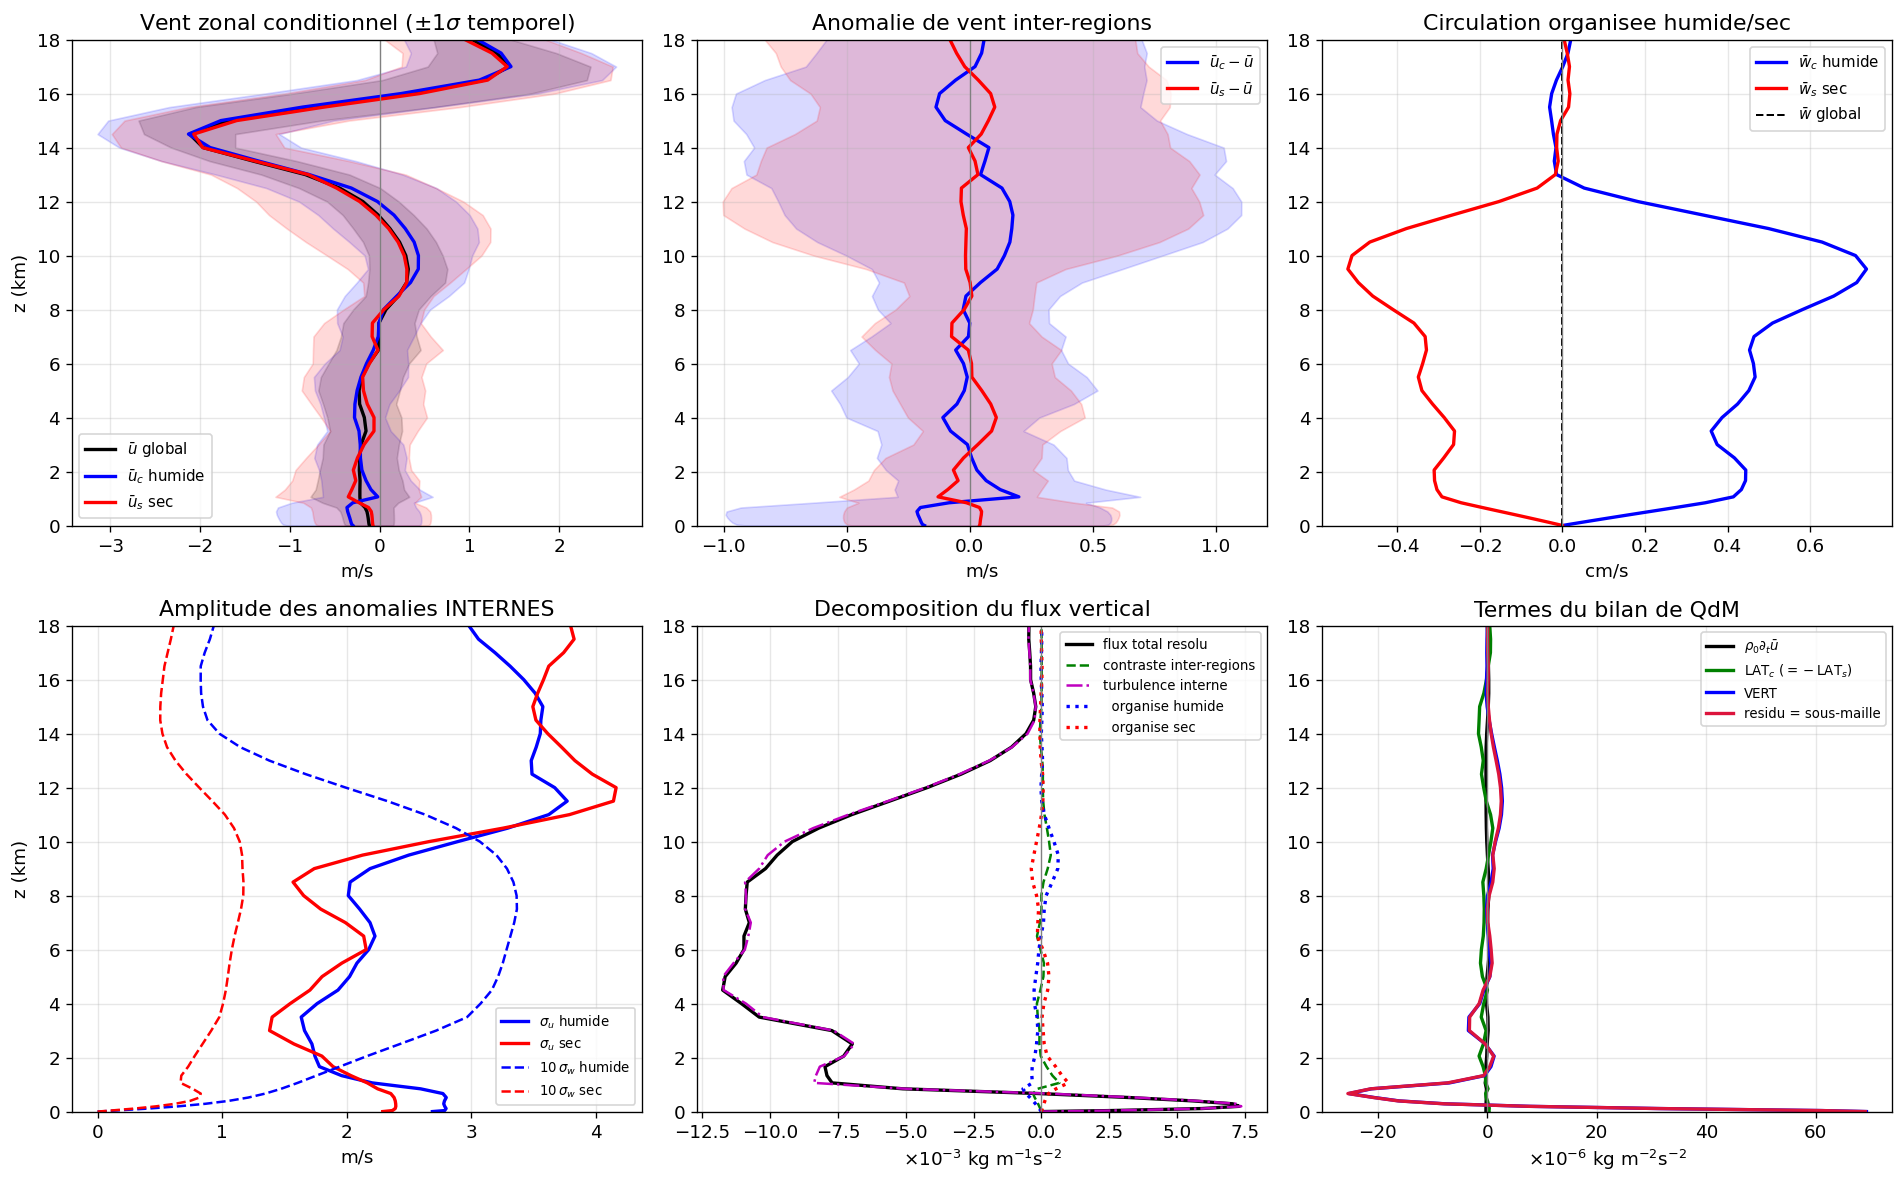

In [9]:
# ============================================================
#  §0bis.C — vents conditionnels, anomalies, amplitudes internes
# ============================================================
import matplotlib.pyplot as plt

su_c = np.sqrt(np.maximum(UUc - Uc**2, 0)); sw_c = np.sqrt(np.maximum(WWc - Wc**2, 0))
su_s = np.sqrt(np.maximum(UUs - Us**2, 0)); sw_s = np.sqrt(np.maximum(WWs - Ws**2, 0))
zk = zkm; m = alt <= 18000

def mt(A): return A.mean(1)
def st(A): return A.std(1)

fig, ax = plt.subplots(2, 3, figsize=(16, 10))

a = ax[0,0]
for A, c, l in [(Ug,'k',r'$\bar u$ global'), (Uc,'b',r'$\bar u_c$ humide'), (Us,'r',r'$\bar u_s$ sec')]:
    a.plot(mt(A)[m], zk[m], color=c, lw=2, label=l)
    a.fill_betweenx(zk[m], (mt(A)-st(A))[m], (mt(A)+st(A))[m], color=c, alpha=.15)
a.axvline(0, color='grey', lw=.8); a.set_xlabel('m/s'); a.set_ylabel('z (km)')
a.set_title(r'Vent zonal conditionnel ($\pm1\sigma$ temporel)'); a.legend(fontsize=9)

a = ax[0,1]
a.plot(mt(dUc)[m], zk[m], 'b', lw=2, label=r'$\bar u_c-\bar u$')
a.plot(mt(dUs)[m], zk[m], 'r', lw=2, label=r'$\bar u_s-\bar u$')
a.fill_betweenx(zk[m], (mt(dUc)-st(dUc))[m], (mt(dUc)+st(dUc))[m], color='b', alpha=.15)
a.fill_betweenx(zk[m], (mt(dUs)-st(dUs))[m], (mt(dUs)+st(dUs))[m], color='r', alpha=.15)
a.axvline(0, color='grey', lw=.8); a.set_xlabel('m/s')
a.set_title("Anomalie de vent inter-regions"); a.legend(fontsize=9)

a = ax[0,2]
a.plot(mt(Wc)[m]*100, zk[m], 'b', lw=2, label=r'$\bar w_c$ humide')
a.plot(mt(Ws)[m]*100, zk[m], 'r', lw=2, label=r'$\bar w_s$ sec')
a.plot(mt(Wg)[m]*100, zk[m], 'k--', lw=1.2, label=r'$\bar w$ global')
a.axvline(0, color='grey', lw=.8); a.set_xlabel('cm/s')
a.set_title('Circulation organisee humide/sec'); a.legend(fontsize=9)

a = ax[1,0]
a.plot(mt(su_c)[m], zk[m], 'b', lw=2, label=r"$\sigma_u$ humide")
a.plot(mt(su_s)[m], zk[m], 'r', lw=2, label=r"$\sigma_u$ sec")
a.plot(mt(sw_c)[m]*10, zk[m], 'b--', lw=1.5, label=r"$10\,\sigma_w$ humide")
a.plot(mt(sw_s)[m]*10, zk[m], 'r--', lw=1.5, label=r"$10\,\sigma_w$ sec")
a.set_xlabel('m/s'); a.set_ylabel('z (km)')
a.set_title("Amplitude des anomalies INTERNES"); a.legend(fontsize=8)

a = ax[1,1]
for A, s, l in [(PHI,'k-','flux total resolu'), (ORG,'g--','contraste inter-regions'),
                (INT,'m-.','turbulence interne'), (MFc,'b:','  organise humide'),
                (MFs,'r:','  organise sec')]:
    a.plot(mt(A)[m]*1e3, zk[m], s, lw=2 if len(s)<3 else 1.5, label=l)
a.axvline(0, color='grey', lw=.8); a.set_xlabel(r'$\times10^{-3}$ kg m$^{-1}$s$^{-2}$')
a.set_title('Decomposition du flux vertical'); a.legend(fontsize=8)

a = ax[1,2]
a.plot(mt(TENc+TENs)[m]*1e6, zk[m], 'k', lw=2, label=r'$\rho_0\partial_t\bar u$')
a.plot(mt(LATc)[m]*1e6, zk[m], 'g', lw=2, label=r'LAT$_c$ ($=-$LAT$_s$)')
a.plot(mt(VERTc+VERTs)[m]*1e6, zk[m], 'b', lw=2, label='VERT')
a.plot(RES_bar[m]*1e6, zk[m], 'crimson', lw=2, label='residu = sous-maille')
a.axvline(0, color='grey', lw=.8); a.set_xlabel(r'$\times10^{-6}$ kg m$^{-2}$s$^{-2}$')
a.set_title('Termes du bilan de QdM'); a.legend(fontsize=8)

for a in ax.ravel(): a.grid(alpha=.3); a.set_ylim(0, 18)
plt.tight_layout(); plt.show()

Le masque dynamique et les moyennes conditionnelles par pas de temps donnent
une image nette de l'organisation humide/sec.

**La circulation organisée est bien réelle et profonde.** $\bar w_c$ atteint
$+0{,}73$ cm/s vers 9,6 km, $\bar w_s$ descend à $-0{,}5$ cm/s : cellule
convective d'échelle du domaine, équilibrée en masse
($f_c\bar w_c+f_s\bar w_s\simeq0$), ascendance dans les colonnes humides et
subsidence compensatrice dans les sèches.

**Mais le contraste zonal est négligeable.** $|\bar u_c-\bar u_s|\lesssim0{,}3$
m/s sur toute la colonne, très en deçà des enveloppes $\pm1\sigma$ temporelles,
qui se recouvrent presque intégralement. Comme le terme de contraste s'écrit
$\mathrm{ORG}=\rho_0\big[f_c\,\delta\bar u_c\,\delta\bar w_c
+f_s\,\delta\bar u_s\,\delta\bar w_s\big]$, il reste faible **non pas parce que
la circulation est faible, mais parce que l'air ascendant humide possède presque
le même vent zonal que la moyenne de domaine**. Le panneau de décomposition le
confirme : la turbulence interne se superpose au flux total.

> **Ce test invalide l'objection méthodologique de la v1.** Le masque figé et les
> moyennes globales faisaient effectivement basculer tout contraste transitoire
> dans le terme interne. Avec un masque instantané et des moyennes par pas de
> temps, cette part est récupérée — et elle reste marginale. La faiblesse du
> contraste est donc un **résultat physique**, pas un artefact de traitement.

Enfin, $\sigma_u$ est comparable dans les deux régions (2–4 m/s, légèrement plus
fort dans le sec en haute troposphère) : le réservoir de fluctuations n'est pas
l'apanage des colonnes convectives. Le pic de surface du bilan
($\sim65\times10^{-6}$ kg m$^{-2}$s$^{-2}$) écrase le reste d'un facteur 20, ce
qui justifie de restreindre l'analyse à la fenêtre 2–18 km.


**Synthèse des deux sections.** La circulation humide/sec transporte peu de
quantité de mouvement *verticalement*, faute de contraste en $\bar u$ (§0bis.C),
mais elle en **échange latéralement** de façon non négligeable (§0bis.D). Une
paramétrisation qui traite chaque colonne indépendamment ignore ce chemin de
communication. La suite du notebook (§1–§2) teste si ce transport se laisse
décrire par une fermeture locale, puis non locale, en verticale.


---
# §1 — Une fermeture grande-échelle reconstruit-elle le flux&nbsp;?

La régression de la synthèse faisait ressortir des termes **tous bâtis sur le cisaillement** $\partial_z\bar u$, modulés par $z$ et $\rho_0$. Cela suggère une fermeture de type **viscosité turbulente** $\rho_0\overline{u'w'}\approx-K(z)\,\partial_z\bar u$, mais avec un $K(z)$ possiblement **signé** (transport contre-gradient).

> **⚠ Correction v2.** Le dictionnaire est très **colinéaire** : `z_dudz` et `zHz_dudz` ont une corrélation de $-1$, `rho0_dudz` et `dudz` de $+0.98$. Le conditionnement de la matrice de design est infini → une régression par moindres carrés ordinaires (`lstsq`) produit des coefficients qui divergent et se compensent, d'où le $R^2<0$ de la v1. On **doit** régulariser (ridge) et/ou élaguer la colinéarité (VIF).

seuil colonne (q=0.90) = 1.08e-02 s-1  |  S : med 7.53e-03  max 1.85e-02
colonnes qualifiees : 9.8 %  (19690 px x-t) en 154 regions connexes >= 6 px
seuil local (q=0.90)  = 5.21e-03 s-1  |  10.0 % des points (x,z,t) de la bande
blocs temporels : train 50 / val 25 / test 25 pas

zone                 modele          NSE_tr   NSE_va   NSE_te  NSE_cst   r_te      cond  rg
toutes               A shear-3       +0.001   +0.001   +0.001   -0.000  +0.03   4.5e+01   3
toutes               B rho0u-3       +0.002   +0.002   +0.001   -0.000  +0.03   2.2e+00   3
toutes               A+B mixte       +0.002   +0.002   +0.001   -0.000  +0.04   1.7e+02   6
toutes               baseline dz     +0.000   +0.000   +0.000   -0.000  +0.01   1.0e+00   1
----------------------------------------------------------------------------------------
colonnes fortes      A shear-3       +0.001   -0.001   -0.000   -0.000  +0.02   5.2e+01   3
colonnes fortes      B rho0u-3       +0.002   +0.001   +0.001   -0.000  +0.03   

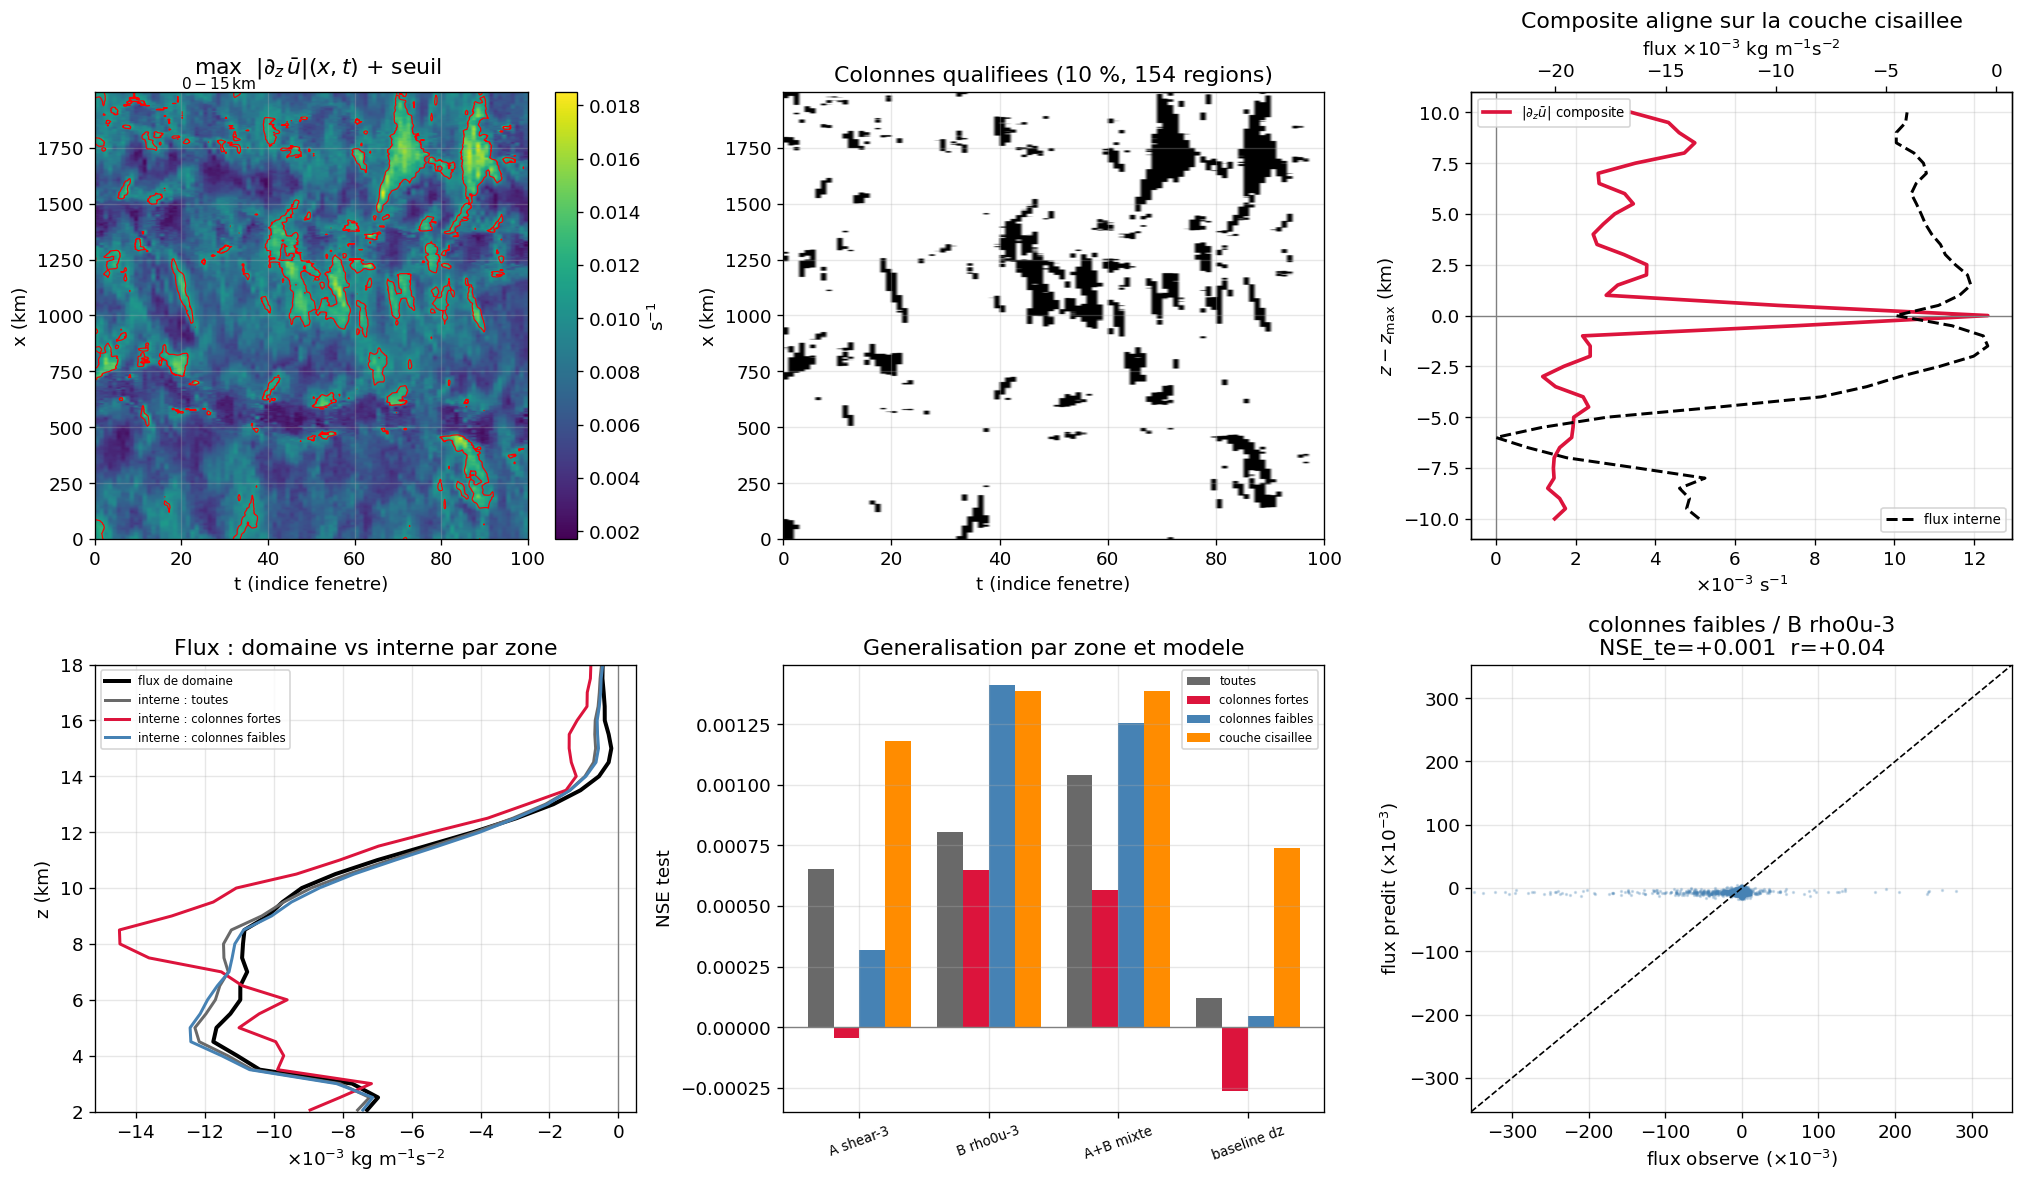

In [10]:
# ============================================================
#  §1 (v4) — FERMETURE LINEAIRE LOCALE TESTEE SUR LES ZONES DE FORT CISAILLEMENT
#
#  v4 corrige deux defauts de la v3 :
#   (1) ridge SANS ordonnee a l'origine + y non centre -> la prediction etait
#       de moyenne nulle par construction (NSE ~ -mean^2/var, sans contenu).
#       Ici : y centre sur le train, intercept non penalise, colonnes
#       constantes ecartees.
#   (2) le critere max_z |dz u| selectionne des colonnes cisaillees, mais la
#       MOYENNE de zone lisse tout (maxima a des z et des signes differents).
#       Ici : l'echantillon de regression est la COLONNE (x,t), pas la moyenne
#       de zone -> le cisaillement de la bibliotheque est celui qu'on a
#       selectionne. Ajout d'un conditionnement local (x,z,t).
#
#  Cible : flux interne a la colonne  rho0 <(u-<u>_y)(w-<w>_y)>_y  (z,t,x)
#  Modeles : (A) c1 dz u + c2 z Hz dz u + c3 z dz u
#            (B) a rho0 u + b dz(rho0 u) + g dzz(rho0 u)
#            (A+B) et baseline 1 terme (dz u seul)
#  Protocole : blocs temporels train/val/test ; alpha sur VAL, score sur TEST.
# ============================================================
import numpy as np, xarray as xr, matplotlib.pyplot as plt, gc
from scipy.ndimage import label, uniform_filter

# ---------------- configuration --------------------------------------
Z_SHEAR_MAX = 15000.0        # fenetre du critere par colonne
Q_SEUIL     = 0.90           # quantile "fort cisaillement" (colonnes)
Q_LOCAL     = 0.90           # quantile "couche cisaillee"  (niveaux)
LISSE_XT    = 0              # lissage de S(x,t) avant seuillage (0 = brut)
MIN_PIX     = 6              # taille min d'une region connexe (px x-t)
Z_LO, Z_HI  = 2000.0, 18000.0
FRAC        = (0.50, 0.25, 0.25)          # train / val / test (blocs temporels)
ALPHAS      = np.logspace(-4, 5, 37)
MAX_SAMP    = 200_000        # plafond d'echantillons par bloc (RAM)
SEED        = 0

zk   = alt/1000.0
band = (alt >= Z_LO) & (alt <= Z_HI); ib = np.where(band)[0]
Hz   = np.gradient(np.log(rho0), alt)     # d ln(rho0)/dz
rng  = np.random.default_rng(SEED)

# ============================================================
#  ETAPE 1 — profils par colonne + flux interne par colonne
# ============================================================
u_y      = np.zeros((n_z, n_stat, n_x), dtype=np.float32)   # <u>_y (x,t)
flux_col = np.zeros((n_z, n_stat, n_x), dtype=np.float32)   # rho0 <u'w'>_y
flux_dom = np.zeros((n_z, n_stat), dtype=np.float64)        # flux de domaine (ref)

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u = ds_u['ua'].isel({dim_t: idx_stat, dim_z: iz}).values.astype(np.float32)
    w = ds_w['wa'].isel({dim_t: idx_stat, dim_z: iz}).values.astype(np.float32)
    uy  = u.mean(axis=1); wy = w.mean(axis=1)                # (n_stat, n_x)
    uwy = (u*w).mean(axis=1)
    u_y[iz]      = uy
    flux_col[iz] = rho0[iz]*(uwy - uy*wy)                    # interne a la colonne
    ug = u.mean(axis=(1, 2)); wg = w.mean(axis=(1, 2))
    flux_dom[iz] = rho0[iz]*((u*w).mean(axis=(1, 2)) - ug*wg)
    del u, w, uy, wy, uwy; gc.collect()
ds_u.close(); ds_w.close(); gc.collect()

dz_uy = np.gradient(u_y, alt, axis=0).astype(np.float32)

# ============================================================
#  ETAPE 2 — detection des zones de fort cisaillement dans (x,t)
# ============================================================
sel_z = alt <= Z_SHEAR_MAX
S     = np.abs(dz_uy[sel_z]).max(axis=0)                     # (n_stat, n_x)
S_f   = uniform_filter(S, LISSE_XT) if LISSE_XT else S
seuil = float(np.quantile(S_f, Q_SEUIL))
brut  = S_f > seuil

lab, nlab = label(brut)                    # x non periodique : cf. note en fin
if MIN_PIX > 1:
    tail = np.bincount(lab.ravel()); tail[0] = 0
    brut = np.isin(lab, np.where(tail >= MIN_PIX)[0])
    lab, nlab = label(brut)
fort, faible = brut, ~brut

# conditionnement LOCAL (niveau par niveau), dans la bande d'etude
absdz  = np.abs(dz_uy)
s_loc  = float(np.quantile(absdz[band], Q_LOCAL))
couche = absdz > s_loc                                        # (n_z, n_stat, n_x)

print(f"seuil colonne (q={Q_SEUIL:.2f}) = {seuil:.2e} s-1  |  "
      f"S : med {np.median(S):.2e}  max {S.max():.2e}")
print(f"colonnes qualifiees : {fort.mean()*100:.1f} %  ({fort.sum()} px x-t) "
      f"en {nlab} regions connexes >= {MIN_PIX} px")
print(f"seuil local (q={Q_LOCAL:.2f})  = {s_loc:.2e} s-1  |  "
      f"{couche[band].mean()*100:.1f} % des points (x,z,t) de la bande")

# ============================================================
#  ETAPE 3 — bibliotheque vectorisee (n_z, n_stat, n_x)
# ============================================================
A3 = alt[:, None, None]; H3 = Hz[:, None, None]; R3 = rho0[:, None, None]

def term(name):
    if name == 'dudz'      : return dz_uy
    if name == 'zHz_dudz'  : return (A3*H3*dz_uy).astype(np.float32)
    if name == 'z_dudz'    : return (A3*dz_uy).astype(np.float32)
    ru = (R3*u_y).astype(np.float32)
    if name == 'rho0_u'    : return ru
    if name == 'dz_rho0_u' : return np.gradient(ru, alt, axis=0).astype(np.float32)
    if name == 'dzz_rho0_u': return np.gradient(np.gradient(ru, alt, axis=0),
                                                alt, axis=0).astype(np.float32)
    raise KeyError(name)

MODELES = {'A shear-3'  : ['dudz', 'zHz_dudz', 'z_dudz'],
           'B rho0u-3'  : ['rho0_u', 'dz_rho0_u', 'dzz_rho0_u'],
           'A+B mixte'  : ['dudz', 'zHz_dudz', 'z_dudz',
                           'rho0_u', 'dz_rho0_u', 'dzz_rho0_u'],
           'baseline dz': ['dudz']}

# ---- zones : masques 3D (n_z, n_stat, n_x) restreints a la bande -----
B3 = band[:, None, None]
ZONES = {'toutes'            : np.broadcast_to(B3, dz_uy.shape),
         'colonnes fortes'   : B3 & fort[None, :, :],
         'colonnes faibles'  : B3 & faible[None, :, :],
         'couche cisaillee'  : B3 & couche}

# ---- decoupage temporel en 3 blocs -----------------------------------
i1 = int(FRAC[0]*n_stat); i2 = int((FRAC[0]+FRAC[1])*n_stat)
TBLOCS = {'tr': np.arange(0, i1), 'va': np.arange(i1, i2), 'te': np.arange(i2, n_stat)}
print(f"blocs temporels : train {i1} / val {i2-i1} / test {n_stat-i2} pas")

def echantillons(zone, ts):
    """indices lineaires d'un sous-ensemble d'echantillons (z,t,x)"""
    m = zone.copy()
    keep_t = np.zeros(n_stat, bool); keep_t[ts] = True
    m &= keep_t[None, :, None]
    idx = np.flatnonzero(m.ravel())
    if idx.size > MAX_SAMP:
        idx = rng.choice(idx, MAX_SAMP, replace=False)
    return idx

def design(names, idx):
    return np.column_stack([term(nm).ravel()[idx].astype(np.float64) for nm in names])

# ============================================================
#  ETAPE 4 — ridge AVEC ordonnee a l'origine, alpha choisi sur VAL
# ============================================================
def nse(o, p): return 1 - np.sum((o-p)**2)/np.sum((o-o.mean())**2)

def ridge(X, y, a):
    mu, sd = X.mean(0), X.std(0)
    keep = sd > 1e-12                       # colonnes constantes ecartees
    sd = np.where(keep, sd, 1.0)
    Z  = ((X-mu)/sd)[:, keep]
    y0 = y.mean()                           # intercept NON penalise
    c  = np.linalg.solve(Z.T@Z + a*np.eye(Z.shape[1]), Z.T@(y-y0))
    return c, mu, sd, y0, keep

def rpred(X, c, mu, sd, y0, keep):
    return ((X-mu)/sd)[:, keep] @ c + y0

def coef_bruts(c, mu, sd, y0, keep, names):
    """coefficients dans les unites physiques + constante"""
    cr = np.zeros(len(names)); cr[keep] = c/sd[keep]
    return cr, y0 - float(cr @ mu)

Y = flux_col.ravel()

def ajuste(zone, names):
    itr, iva, ite = (echantillons(zone, TBLOCS[k]) for k in ('tr', 'va', 'te'))
    if min(itr.size, iva.size, ite.size) < 500: return None
    Xtr, Xva, Xte = design(names, itr), design(names, iva), design(names, ite)
    ytr, yva, yte = Y[itr].astype(np.float64), Y[iva].astype(np.float64), Y[ite].astype(np.float64)
    Zs = (Xtr - Xtr.mean(0))/(Xtr.std(0) + 1e-30)
    sv = np.linalg.svd(Zs, compute_uv=False)
    fits = [ridge(Xtr, ytr, a) for a in ALPHAS]
    sc   = [nse(yva, rpred(Xva, *f)) for f in fits]
    k = int(np.argmax(sc)); f = fits[k]
    pte = rpred(Xte, *f)
    cr, b0 = coef_bruts(*f, names)
    return dict(alpha=ALPHAS[k], names=names, fit=f, coef_bruts=cr, const=b0,
                nse_tr=nse(ytr, rpred(Xtr, *f)), nse_va=sc[k], nse_te=nse(yte, pte),
                nse_cst=nse(yte, np.full_like(yte, ytr.mean())),
                r_te=float(np.corrcoef(yte, pte)[0, 1]),
                cond=sv[0]/max(sv[-1], 1e-30),
                rang=int(np.sum(sv > sv[0]*1e-8)), sv=sv/sv[0],
                n_tr=itr.size, ite=ite, pte=pte, yte=yte)

RES = {}
print("\n" + "="*88)
print(f"{'zone':20s} {'modele':13s} {'NSE_tr':>8s} {'NSE_va':>8s} {'NSE_te':>8s}"
      f" {'NSE_cst':>8s} {'r_te':>6s} {'cond':>9s} {'rg':>3s}")
print("="*88)
for zn, zm in ZONES.items():
    for mn, nms in MODELES.items():
        r = ajuste(zm, nms)
        if r is None:
            print(f"{zn:20s} {mn:13s}   echantillon insuffisant"); continue
        RES[(zn, mn)] = r
        print(f"{zn:20s} {mn:13s} {r['nse_tr']:+8.3f} {r['nse_va']:+8.3f}"
              f" {r['nse_te']:+8.3f} {r['nse_cst']:+8.3f} {r['r_te']:+6.2f}"
              f" {r['cond']:9.1e} {r['rang']:3d}")
    print("-"*88)

# ---- diagnostics de rang et viscosite implicite -----------------------
for zn in ['colonnes fortes', 'couche cisaillee']:
    r = RES.get((zn, 'A shear-3'))
    if r is None: continue
    print(f"\n[{zn}] spectre singulier modele A : "
          f"{np.array2string(r['sv'], precision=4)}")
    if r['sv'][-1] < 1e-2:
        print("  -> 3e direction quasi nulle : c2 et c3 ne sont pas identifiables "
              "separement (z*Hz et z quasi colineaires sur 2-18 km).")
    bl = RES.get((zn, 'baseline dz'))
    if bl is not None:
        print(f"  gain de A sur la baseline 1 terme (NSE test) : "
              f"{r['nse_te']-bl['nse_te']:+.3f}")
        K = -bl['coef_bruts'][0]
        print(f"  viscosite implicite de la baseline : K = {K:+.2f} kg m-1 s-1 "
              f"({'DOWN-gradient' if K > 0 else 'CONTRE-gradient (K<0) !'})")

# ============================================================
#  ETAPE 5 — composite aligne sur l'altitude du maximum de cisaillement
#  (montre que le conditionnement preserve bien le cisaillement)
# ============================================================
it_, ix_ = np.where(fort)
sub = rng.choice(it_.size, min(it_.size, 20000), replace=False)
it_, ix_ = it_[sub], ix_[sub]
izs = np.where(sel_z)[0]
izm = izs[np.argmax(np.abs(dz_uy[np.ix_(izs, )][:, it_, ix_]), axis=0)]

NOFF = 20
offs = np.arange(-NOFF, NOFF+1)
comp_s = np.full(offs.size, np.nan); comp_f = np.full(offs.size, np.nan)
for j, o in enumerate(offs):
    iz = izm + o; ok = (iz >= 0) & (iz < n_z)
    if ok.sum() < 50: continue
    comp_s[j] = np.abs(dz_uy[iz[ok], it_[ok], ix_[ok]]).mean()
    comp_f[j] = flux_col[iz[ok], it_[ok], ix_[ok]].mean()
dzm = offs*float(np.median(np.diff(alt)))/1000.0

sh_comp = np.nanmax(comp_s)
sh_zone = float(np.abs(np.gradient(u_y[:, :, :].mean(axis=(1, 2)), alt))[band].max())
print(f"\ncisaillement au coeur du composite : {sh_comp:.2e} s-1")
print(f"cisaillement du profil moyen de domaine : {sh_zone:.2e} s-1"
      f"   (rapport {sh_comp/max(sh_zone,1e-30):.0f}x)")
print("=> c'est bien la moyenne d'ensemble qui detruisait le signal en v3.")

# ============================================================
#  FIGURES
# ============================================================
fig, ax = plt.subplots(2, 3, figsize=(17, 10))
xkm = np.arange(n_x)*dx/1000.0
ext = [0, n_stat, xkm[0], xkm[-1]]

a = ax[0, 0]; a.grid(False)
im = a.imshow(S_f.T, origin='lower', aspect='auto', extent=ext, cmap='viridis')
a.contour(np.linspace(0, n_stat, n_stat), xkm, S_f.T, [seuil], colors='r', linewidths=.7)
a.set_xlabel('t (indice fenetre)'); a.set_ylabel('x (km)')
a.set_title(r'$\max_{0-15\,\mathrm{km}}|\partial_z\bar u|(x,t)$ + seuil')
fig.colorbar(im, ax=a, label=r's$^{-1}$')

a = ax[0, 1]; a.grid(False)
a.imshow(fort.T, origin='lower', aspect='auto', extent=ext, cmap='gray_r')
a.set_xlabel('t (indice fenetre)'); a.set_ylabel('x (km)')
a.set_title(f'Colonnes qualifiees ({fort.mean()*100:.0f} %, {nlab} regions)')

a = ax[0, 2]
a.plot(comp_s*1e3, dzm, 'crimson', lw=2.2, label=r'$|\partial_z\bar u|$ composite')
a.axhline(0, color='grey', lw=.8); a.axvline(0, color='grey', lw=.8)
a.set_xlabel(r'$\times10^{-3}$ s$^{-1}$'); a.set_ylabel(r'$z-z_{\max}$ (km)')
a.set_title('Composite aligne sur la couche cisaillee')
a2 = a.twiny(); a2.plot(comp_f*1e3, dzm, 'k--', lw=1.8, label='flux interne')
a2.set_xlabel(r'flux $\times10^{-3}$ kg m$^{-1}$s$^{-2}$'); a2.grid(False)
a.legend(fontsize=8, loc='upper left'); a2.legend(fontsize=8, loc='lower right')

a = ax[1, 0]
a.plot(flux_dom.mean(1)[band]*1e3, zk[band], 'k-', lw=2.4, label='flux de domaine')
for zn, c in zip(['toutes', 'colonnes fortes', 'colonnes faibles'],
                 ['dimgrey', 'crimson', 'steelblue']):
    m = ZONES[zn]
    num = (flux_col*m).sum(axis=(1, 2)); den = m.sum(axis=(1, 2))
    a.plot(np.where(den > 0, num/np.maximum(den, 1), np.nan)[band]*1e3, zk[band],
           color=c, lw=1.8, label=f'interne : {zn}')
a.axvline(0, color='grey', lw=.8); a.set_xlabel(r'$\times10^{-3}$ kg m$^{-1}$s$^{-2}$')
a.set_ylabel('z (km)'); a.set_title('Flux : domaine vs interne par zone')
a.legend(fontsize=7); a.set_ylim(Z_LO/1000, Z_HI/1000)

a = ax[1, 1]
lm = list(MODELES); lz = list(ZONES); w = 0.2
for i, (zn, c) in enumerate(zip(lz, ['dimgrey', 'crimson', 'steelblue', 'darkorange'])):
    v = [RES[(zn, m)]['nse_te'] if (zn, m) in RES else np.nan for m in lm]
    a.bar(np.arange(len(lm)) + (i-1.5)*w, v, w, color=c, label=zn)
a.axhline(0, color='grey', lw=.8)
a.set_xticks(range(len(lm))); a.set_xticklabels(lm, rotation=20, fontsize=8)
a.set_ylabel('NSE test'); a.set_title('Generalisation par zone et modele')
a.legend(fontsize=7)

a = ax[1, 2]
best = max((k for k in RES), key=lambda k: RES[k]['nse_te'])
rb = RES[best]
n_pt = min(4000, rb['yte'].size); pick = rng.choice(rb['yte'].size, n_pt, replace=False)
a.plot(rb['yte'][pick]*1e3, rb['pte'][pick]*1e3, '.', ms=2, alpha=.25, color='steelblue')
lim = np.percentile(np.abs(rb['yte'])*1e3, 99.5)
a.plot([-lim, lim], [-lim, lim], 'k--', lw=1)
a.set_xlim(-lim, lim); a.set_ylim(-lim, lim)
a.set_xlabel(r'flux observe ($\times10^{-3}$)'); a.set_ylabel(r'flux predit ($\times10^{-3}$)')
a.set_title(f'{best[0]} / {best[1]}\nNSE_te={rb["nse_te"]:+.3f}  r={rb["r_te"]:+.2f}')

for a in ax.ravel(): a.grid(alpha=.3)
plt.tight_layout(); plt.show()



toutes             A shear-3    NSE=+0.089  r=+0.30  K_implicite=+1.5 kg m-1 s-1
toutes             baseline dz  NSE=+0.020  r=+0.14  K_implicite=+0.3 kg m-1 s-1
colonnes fortes    A shear-3    NSE=+0.076  r=+0.27  K_implicite=+0.9 kg m-1 s-1
colonnes fortes    baseline dz  NSE=+0.021  r=+0.15  K_implicite=+0.3 kg m-1 s-1
colonnes faibles   A shear-3    NSE=+0.087  r=+0.30  K_implicite=+1.6 kg m-1 s-1
colonnes faibles   baseline dz  NSE=+0.019  r=+0.14  K_implicite=+0.3 kg m-1 s-1
couche cisaillee   A shear-3    NSE=-0.086  r=+0.24  K_implicite=+0.8 kg m-1 s-1
couche cisaillee   baseline dz  NSE=-0.123  r=+0.18  K_implicite=+0.1 kg m-1 s-1


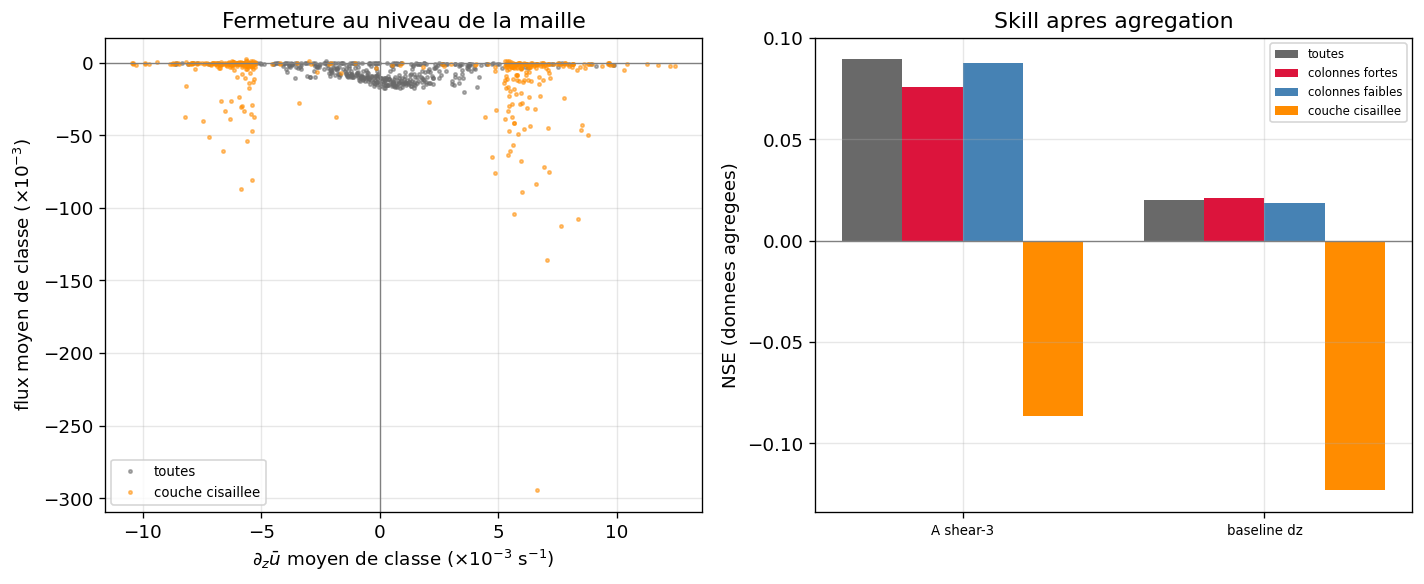

In [11]:
# ============================================================
#  §1bis — FERMETURE AU NIVEAU DE LA MAILLE (agregation intermediaire)
#  v3 : moyenne globale -> cisaillement lisse a zero
#  v4 : colonne individuelle -> bruit turbulent (rapport 30:1)
#  ici : moyennes conditionnelles PAR CLASSE DE CISAILLEMENT, niveau par
#  niveau. C'est l'echelle a laquelle une parametrisation opere.
# ============================================================
NBIN = 12
res_bin = {}
for zn, zm in ZONES.items():
    Xs, Ys, Ns = [], [], []
    for k, iz in enumerate(ib):
        s = dz_uy[iz][zm[iz]]; f = flux_col[iz][zm[iz]]
        if s.size < 200: continue
        qs = np.quantile(s, np.linspace(0, 1, NBIN+1)); qs[-1] += 1e-12
        d  = np.digitize(s, qs[1:-1])
        for j in range(NBIN):
            m = d == j
            if m.sum() < 30: continue
            Xs.append([s[m].mean(), alt[iz], rho0[iz]]); Ys.append(f[m].mean())
            Ns.append(m.sum())
    if len(Ys) < 30: continue
    Xs = np.array(Xs); Ys = np.array(Ys); Ns = np.array(Ns)
    du, zz, rr = Xs[:, 0], Xs[:, 1], Xs[:, 2]
    D = {'A shear-3': np.column_stack([du, zz*np.interp(zz, alt, Hz)*du, zz*du]),
         'baseline dz': du[:, None]}
    for mn, M in D.items():
        M1 = np.column_stack([M, np.ones(len(Ys))])
        w  = np.sqrt(Ns)                                  # pondere par l'effectif
        c, *_ = np.linalg.lstsq(M1*w[:, None], Ys*w, rcond=None)
        p = M1 @ c
        res_bin[(zn, mn)] = (nse(Ys, p), float(np.corrcoef(Ys, p)[0, 1]), c)
        print(f"{zn:18s} {mn:12s} NSE={nse(Ys,p):+.3f}  r={np.corrcoef(Ys,p)[0,1]:+.2f}"
              f"  K_implicite={-c[0]:+.1f} kg m-1 s-1")

# --- la relation flux <-> cisaillement, en moyenne conditionnelle ------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for zn, c in zip(['toutes', 'couche cisaillee'], ['dimgrey', 'darkorange']):
    zm = ZONES[zn]; sv, fv = [], []
    for iz in ib:
        s = dz_uy[iz][zm[iz]]; f = flux_col[iz][zm[iz]]
        if s.size < 200: continue
        qs = np.quantile(s, np.linspace(0, 1, NBIN+1)); qs[-1] += 1e-12
        d = np.digitize(s, qs[1:-1])
        for j in range(NBIN):
            m = d == j
            if m.sum() >= 30: sv.append(s[m].mean()); fv.append(f[m].mean())
    ax[0].plot(np.array(sv)*1e3, np.array(fv)*1e3, '.', ms=4, alpha=.5, color=c, label=zn)
ax[0].axhline(0, color='grey', lw=.8); ax[0].axvline(0, color='grey', lw=.8)
ax[0].set_xlabel(r'$\partial_z\bar u$ moyen de classe ($\times10^{-3}$ s$^{-1}$)')
ax[0].set_ylabel(r'flux moyen de classe ($\times10^{-3}$)')
ax[0].set_title('Fermeture au niveau de la maille'); ax[0].legend(fontsize=8)

lm = ['A shear-3', 'baseline dz']
for i, (zn, c) in enumerate(zip(ZONES, ['dimgrey', 'crimson', 'steelblue', 'darkorange'])):
    v = [res_bin[(zn, m)][0] if (zn, m) in res_bin else np.nan for m in lm]
    ax[1].bar(np.arange(len(lm)) + (i-1.5)*0.2, v, 0.2, color=c, label=zn)
ax[1].axhline(0, color='grey', lw=.8); ax[1].set_xticks(range(len(lm)))
ax[1].set_xticklabels(lm, fontsize=8); ax[1].set_ylabel('NSE (donnees agregees)')
ax[1].set_title('Skill apres agregation'); ax[1].legend(fontsize=7)
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

---
# §3 — À quelle vitesse la QdM parcourt-elle la colonne&nbsp;? (propagation)

Corrélation retardée entre une référence basse et le flux à chaque niveau :
$C(z,\tau)=\mathrm{corr}(\Phi_{\rm ref}(t),\Phi(z,t+\tau))$. Le retard $\tau^\star(z)$ du maximum donne une vitesse de propagation verticale.

> **Robustesse v2.** Avec seulement $n=100$ pas de 6 h, les corrélations à grand $|\tau|$ sont peu fiables. On ajoute : (i) un **intervalle de confiance** ($\pm 2/\sqrt{n_{\rm eff}}$), (ii) un **masque** ne gardant que les niveaux où $|C|_{\max}$ dépasse le seuil de significativité, (iii) une restriction de $\tau$ à une fenêtre physique ($|\tau|\le 120$ h).

In [12]:
# ============================================================
#  §3.1  Corrélation retardée + seuil de significativité
# ============================================================
from scipy.signal import detrend
iz_ref=np.argmin(np.abs(alt-1000.0))
ref=detrend(flux_zt[iz_ref,:]); ref=(ref-ref.mean())/(ref.std()+1e-30)
Fana=detrend(flux_zt[band,:],axis=1)
Fana=(Fana-Fana.mean(1,keepdims=True))/(Fana.std(1,keepdims=True)+1e-30)
zc_km=zkm[band]

TAU_MAX_H=120.0
Lmax=int(TAU_MAX_H*3600/dt_phys)
lags=np.arange(-Lmax,Lmax+1)
C=np.zeros((band.sum(),lags.size))
for j,L in enumerate(lags):
    if L>=0: a=ref[:n_stat-L]; bb=Fana[:,L:]
    else:    a=ref[-L:];       bb=Fana[:,:n_stat+L]
    C[:,j]=(bb*a).mean(1)

# seuil de significativité ~ 2/sqrt(n_eff), n_eff réduit par l'autocorrélation
n_eff=max(n_stat//3,10)                      # prudent (autocorrélation temporelle)
sig=2/np.sqrt(n_eff)
Cmax=np.max(np.abs(C),axis=1)
tau_star=lags[np.argmax(np.abs(C),axis=1)]*dt_phys/3600.0
signif=Cmax>sig
print(f"seuil de significativité |C|>{sig:.2f}  (n_eff≈{n_eff})")
print(f"niveaux significatifs : {signif.sum()}/{band.sum()}")
print(f"retards significatifs : {tau_star[signif].min():.0f} à {tau_star[signif].max():.0f} h")


seuil de significativité |C|>0.35  (n_eff≈33)
niveaux significatifs : 19/33
retards significatifs : -84 à 102 h


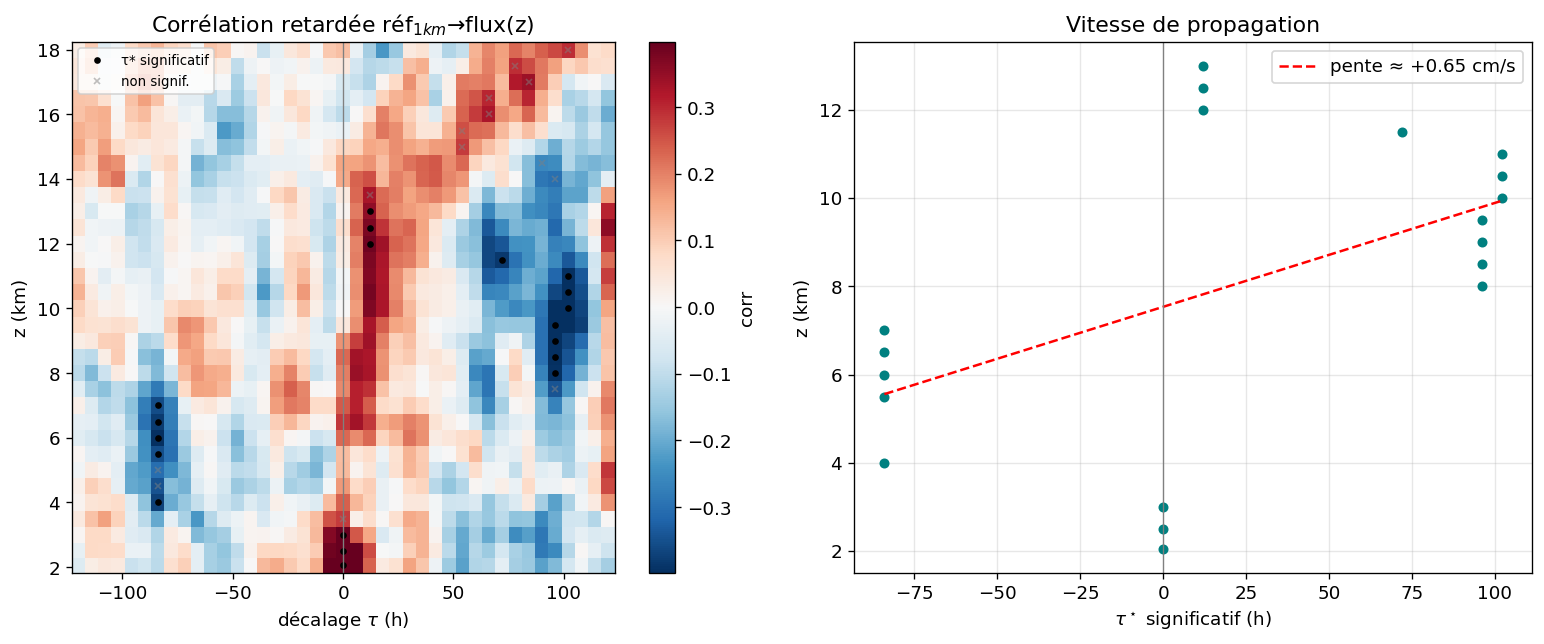

vitesse de propagation ≈ +0.65 cm/s
Lecture honnête : si peu de niveaux passent le seuil, la propagation n'est pas
résolue par la sortie 6-horaire ; le résultat exploitable reste le noyau spatial (§2).


In [13]:
# ============================================================
#  §3.2  Figure : corrélation retardée + tau* SEULEMENT si significatif
# ============================================================
fig,axes=plt.subplots(1,2,figsize=(13,5.5))
lags_h=lags*dt_phys/3600.0

ax=axes[0]; ax.grid(False)
v=np.percentile(np.abs(C),99)
im=ax.pcolormesh(lags_h,zc_km,C,cmap='RdBu_r',norm=TwoSlopeNorm(0,-v,v),shading='auto')
ax.plot(tau_star[signif],zc_km[signif],'k.',ms=6,label='τ* significatif')
ax.plot(tau_star[~signif],zc_km[~signif],'x',color='grey',ms=4,alpha=.5,label='non signif.')
ax.axvline(0,color='grey',lw=.8)
ax.set_xlabel(r'décalage $\tau$ (h)'); ax.set_ylabel('z (km)')
ax.set_title(r'Corrélation retardée réf$_{1km}\to$flux(z)'); ax.legend(fontsize=8)
fig.colorbar(im,ax=ax,label='corr')

ax=axes[1]
ax.plot(tau_star[signif],zc_km[signif],'o',color='teal',ms=5)
if signif.sum()>=4 and np.ptp(tau_star[signif])>0:
    p=np.polyfit(tau_star[signif],zc_km[signif],1)
    cz=p[0]*1000/3600*100
    tt=np.linspace(tau_star[signif].min(),tau_star[signif].max(),20)
    ax.plot(tt,np.polyval(p,tt),'r--',label=f'pente ≈ {cz:+.2f} cm/s')
    ax.legend()
    txt=f"vitesse de propagation ≈ {cz:+.2f} cm/s"
else:
    txt="trop peu de niveaux significatifs pour une vitesse fiable"
ax.axvline(0,color='grey',lw=.8)
ax.set_xlabel(r'$\tau^\star$ significatif (h)'); ax.set_ylabel('z (km)')
ax.set_title('Vitesse de propagation'); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
print(txt)
print("Lecture honnête : si peu de niveaux passent le seuil, la propagation n'est pas")
print("résolue par la sortie 6-horaire ; le résultat exploitable reste le noyau spatial (§2).")


 seuil w  C median        C p25-p75  sigma@6km
    0.00    -8.104  -9.448  -6.567     46.30%
    0.25    -2.473  -3.446  -1.661      1.43%
    0.50    -3.107  -4.143  -2.432      0.55%
    1.00    -3.406  -4.814  -2.791      0.23%
    2.00    -2.916  -3.339  -2.628      0.10%


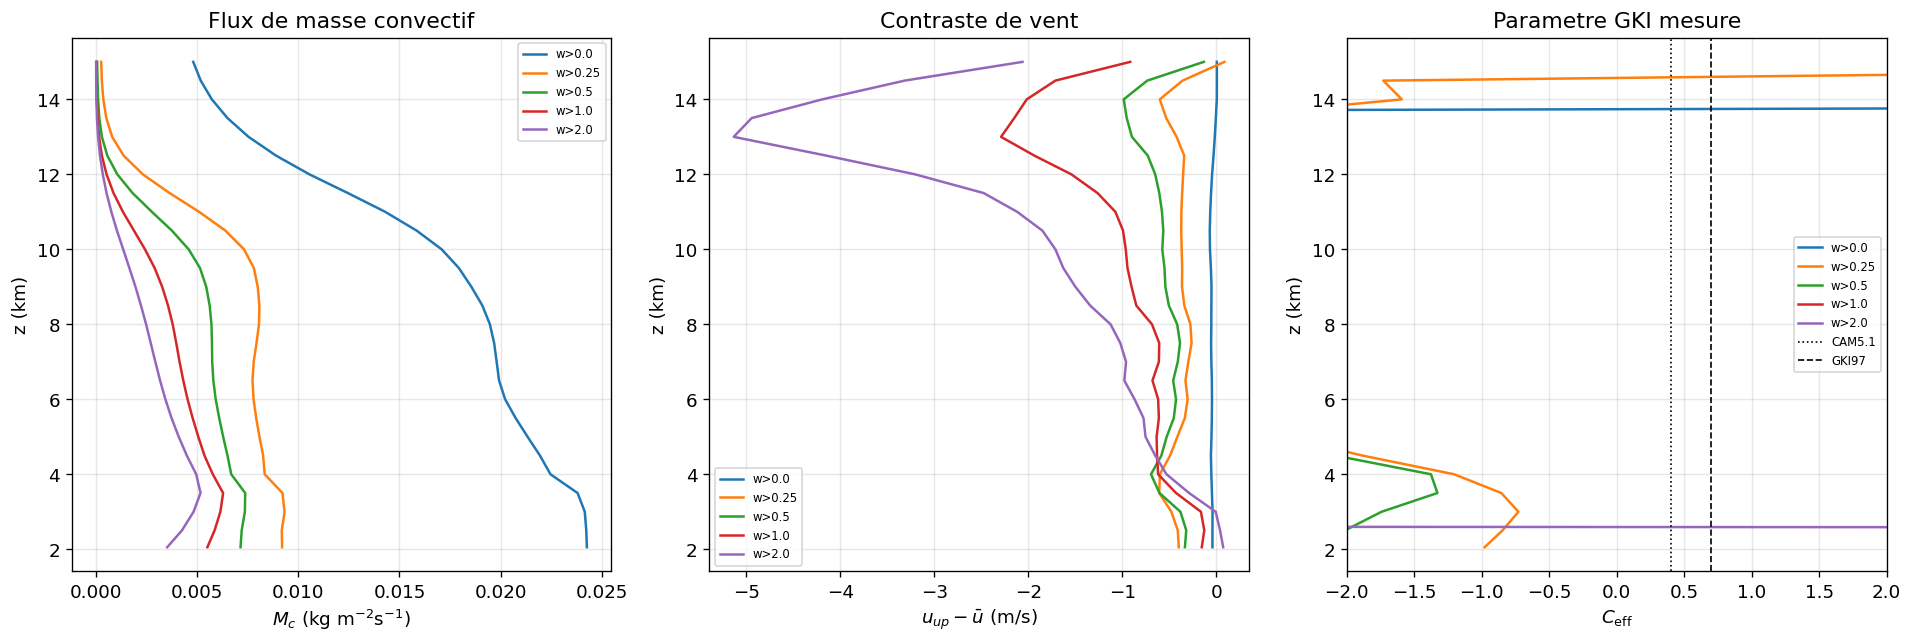

In [14]:
# ============================================================
#  §A — PARAMETRE C DU SCHEMA GKI, MESURE SUR large300
#  Romps (2012) : flux_GKI(C) == (1-C) * Mc * (u_up - ubar)
#  => C_eff(z) = 1 - Phi_vrai / [ Mc (u_up - ubar) ]
#  Balayage du seuil updraft : C doit etre ROBUSTE au seuil,
#  sinon ce n'est pas un parametre physique.
# ============================================================
import numpy as np, xarray as xr, gc, matplotlib.pyplot as plt

SEUILS = [0.0, 0.25, 0.5, 1.0, 2.0]          # m/s, seuil w des updrafts
band   = (alt >= 2000) & (alt <= 15000)

sig = {s: np.zeros(n_z) for s in SEUILS}
wup = {s: np.zeros(n_z) for s in SEUILS}
uup = {s: np.zeros(n_z) for s in SEUILS}
ubar_p, wbar_p, Phi = np.zeros(n_z), np.zeros(n_z), np.zeros(n_z)

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u = ds_u['ua'].isel({dim_t: idx_stat, dim_z: iz}).values.astype(np.float32)
    w = ds_w['wa'].isel({dim_t: idx_stat, dim_z: iz}).values.astype(np.float32)
    ub, wb = float(u.mean()), float(w.mean())
    ubar_p[iz], wbar_p[iz] = ub, wb
    Phi[iz] = rho0[iz]*(float((u*w).mean()) - ub*wb)
    for s in SEUILS:
        m = w > s
        n = int(m.sum())
        if n < 100: sig[s][iz] = np.nan; continue
        sig[s][iz] = n/u.size
        wup[s][iz] = float(w[m].mean()); uup[s][iz] = float(u[m].mean())
    del u, w; gc.collect()
ds_u.close(); ds_w.close()

fig, ax = plt.subplots(1, 3, figsize=(16, 5.5))
print(f"{'seuil w':>8s} {'C median':>9s} {'C p25-p75':>16s} {'sigma@6km':>10s}")
for s in SEUILS:
    Mc    = rho0*sig[s]*(wup[s] - wbar_p)             # flux de masse convectif
    Phi_ZD = Mc*(uup[s] - ubar_p)                      # forme zero-drag (SL76)
    with np.errstate(invalid='ignore', divide='ignore'):
        C = 1.0 - Phi/np.where(np.abs(Phi_ZD) < 1e-12, np.nan, Phi_ZD)
    b = band & np.isfinite(C)
    q = np.nanpercentile(C[b], [25, 50, 75])
    i6 = np.argmin(np.abs(alt-6000))
    print(f"{s:8.2f} {q[1]:+9.3f} {q[0]:+7.3f} {q[2]:+7.3f} {sig[s][i6]*100:9.2f}%")
    ax[0].plot(Mc[band], alt[band]/1e3, label=f'w>{s}')
    ax[1].plot((uup[s]-ubar_p)[band], alt[band]/1e3, label=f'w>{s}')
    ax[2].plot(C[b], alt[b]/1e3, label=f'w>{s}')

ax[0].set_xlabel(r'$M_c$ (kg m$^{-2}$s$^{-1}$)'); ax[0].set_title('Flux de masse convectif')
ax[1].set_xlabel(r'$u_{up}-\bar u$ (m/s)');       ax[1].set_title('Contraste de vent')
ax[2].axvline(0.4, color='k', ls=':', lw=1, label='CAM5.1')
ax[2].axvline(0.7, color='k', ls='--', lw=1, label='GKI97')
ax[2].set_xlim(-2, 2); ax[2].set_xlabel(r'$C_{\rm eff}$'); ax[2].set_title('Parametre GKI mesure')
for a in ax: a.set_ylabel('z (km)'); a.grid(alpha=.3); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

Modes DMD dominants (energie de QdM) :
 #    T (j)  c_z (cm/s)   tau (j)   poids
 6      nan         nan     20.07   1.000
10     9.07    -120.683      2.13   0.786
11     9.07    -120.683      2.13   0.786
 2     5.35      -1.568     10.39   0.710
 3     5.35      -1.568     10.39   0.710
 8    15.17      -1.188      6.51   0.682
 9    15.17      -1.188      6.51   0.682
 7      nan         nan      2.24   0.677

noyau : lambda*=1.23e+00  NSE test=+0.182  NSE in-sample=+0.391

Modes propres de l'operateur K (a comparer au DMD) :
   T= 10.00 j   c_z= -1.241 cm/s   tau=  26.42 j
   T= 10.00 j   c_z= -1.241 cm/s   tau=  26.42 j
   T= 30.27 j   c_z= +1.289 cm/s   tau=  49.86 j
   T= 30.27 j   c_z= +1.289 cm/s   tau=  49.86 j
   T=616.42 j   c_z= -0.007 cm/s   tau= 142.43 j


/tmp/ipykernel_16429/3423677772.py:108: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax[2].pcolormesh(zb/1e3, zb/1e3, K, cmap='RdBu_r', shading='auto',
/tmp/ipykernel_16429/3423677772.py:115: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax[3].pcolormesh(np.arange(Sa.shape[1]), zb/1e3, rec, cmap='RdBu_r', shading='auto')


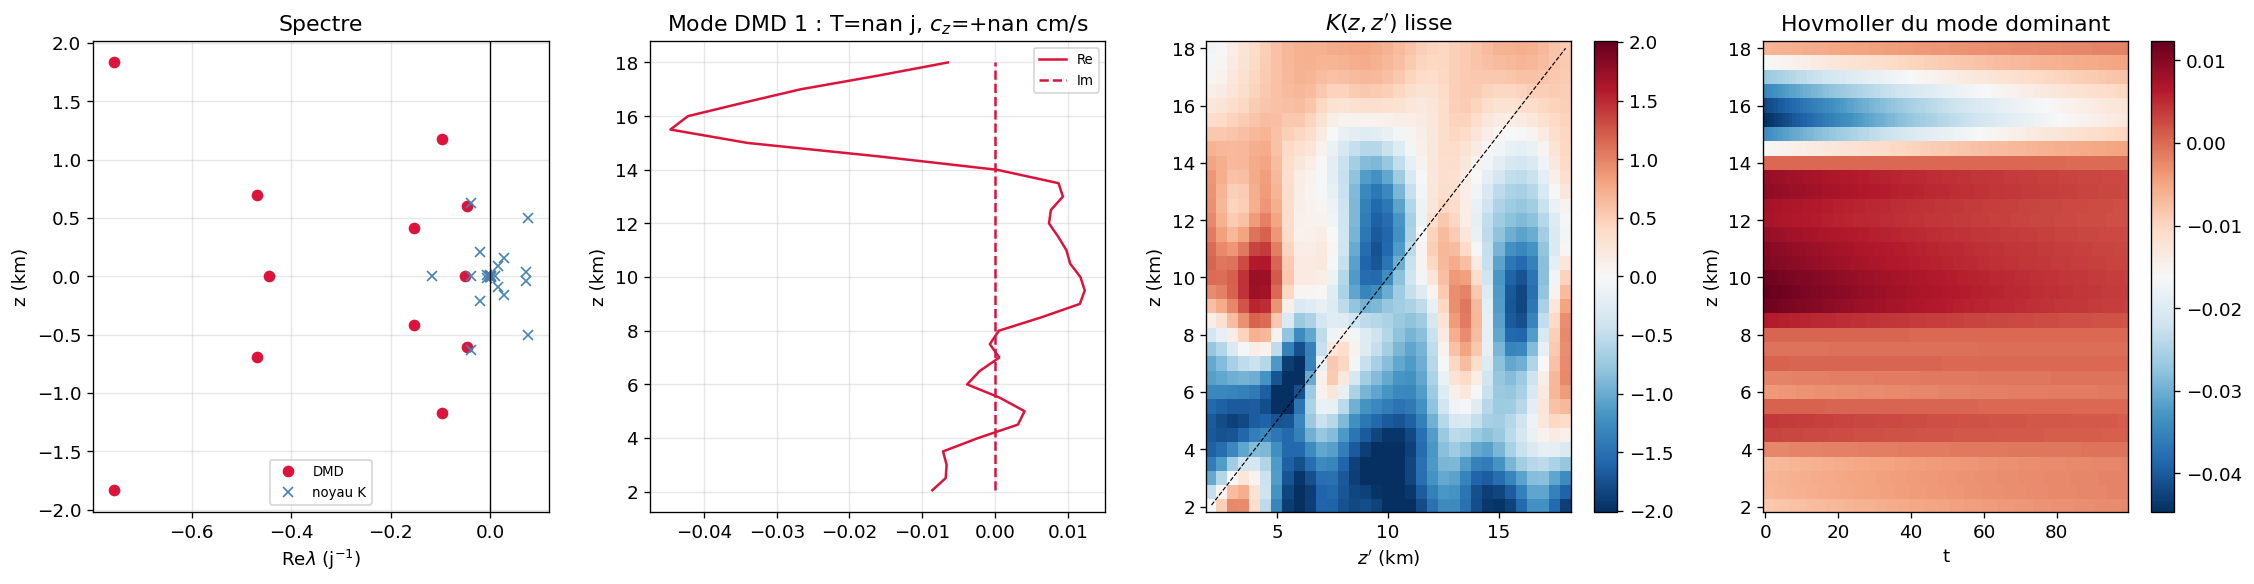

In [15]:
# ============================================================
#  §B — OPERATEUR DE REPONSE DE LA QdM + MODES PROPRES
#   B1  DMD sur ubar(z,t)      -> periode, c_z, temps d'amortissement
#   B2  noyau K(z,z') contraint (Sylvester) -> flux' = K * shear'
#   B3  M = -(1/rho0) d/dz [ K d/dz ]  -> modes propres, comparaison a B1
#  Norme d'energie : poids sqrt(rho0*dz) (les modes sont alors des
#  structures de QdM, pas de vitesse).
# ============================================================
import numpy as np, matplotlib.pyplot as plt
from scipy.linalg import solve_sylvester

band = (alt >= 2000) & (alt <= 18000); ib = np.where(band)[0]
zb, rb = alt[ib], rho0[ib]; nb = ib.size
dzb = np.gradient(zb)
wgt = np.sqrt(rb*dzb); Wm = np.diag(wgt); Wi = np.diag(1/wgt)

U = ubar_zt[ib] - ubar_zt[ib].mean(1, keepdims=True)
Uw = Wm @ U

# ---------- B1 : DMD ---------------------------------------------------
R_DMD = 12
X1, X2 = Uw[:, :-1], Uw[:, 1:]
Q, S, Vt = np.linalg.svd(X1, full_matrices=False)
r = min(R_DMD, int(np.sum(S > S[0]*1e-10)))
Qr, Sr, Vr = Q[:, :r], S[:r], Vt[:r].T
Atil = Qr.T @ X2 @ Vr @ np.diag(1/Sr)
mu, Wv = np.linalg.eig(Atil)
lam = np.log(mu.astype(complex))/dt_phys
Modes = Wi @ (X2 @ Vr @ np.diag(1/Sr) @ Wv)

def carac(phi, lm):
    om = float(np.imag(lm))
    if abs(om) < 1e-12: return np.nan, np.nan
    T = 2*np.pi/abs(om)/86400.0
    th = np.unwrap(np.angle(phi))
    a  = np.abs(phi); k = a > 0.25*a.max()
    if k.sum() < 5: return T, np.nan
    m = np.polyfit(zb[k], th[k], 1)[0]
    return T, (-om/m*100 if abs(m) > 1e-9 else np.nan)   # cm/s

print("Modes DMD dominants (energie de QdM) :")
print(f"{'#':>2s} {'T (j)':>8s} {'c_z (cm/s)':>11s} {'tau (j)':>9s} {'poids':>7s}")
amp = np.linalg.norm(Modes, axis=0)*np.abs(Qr.T @ Uw[:, 0] @ np.ones(1) if False else 1)
ordre = np.argsort(-np.abs(np.imag(lam)) * 0 - amp)      # tri par amplitude
for j in ordre[:8]:
    T, cz = carac(Modes[:, j], lam[j])
    tau = -1/np.real(lam[j])/86400 if np.real(lam[j]) < 0 else np.inf
    print(f"{j:2d} {T:8.2f} {cz:11.3f} {tau:9.2f} {amp[j]/amp.max():7.3f}")

# ---------- B2 : noyau contraint --------------------------------------
S_zt = np.gradient(ubar_zt, alt, axis=0)[ib]
Sa = S_zt - S_zt.mean(1, keepdims=True)
Fa = flux_zt[ib] - flux_zt[ib].mean(1, keepdims=True)

L = np.zeros((nb, nb))                                    # laplacien 1D
for i in range(1, nb-1): L[i, i-1:i+2] = [1, -2, 1]
L[0, :2] = [-1, 1]; L[-1, -2:] = [1, -1]
LtL = L.T @ L
sc  = np.trace(Sa @ Sa.T)/nb

def kernel(lr, lc):
    A = lr*sc*LtL
    B = Sa @ Sa.T + lc*sc*LtL
    return solve_sylvester(A + 1e-12*np.eye(nb), B, Fa @ Sa.T)

def nse(o, p): return 1 - np.sum((o-p)**2)/np.sum((o-o.mean())**2)
tsp = int(0.7*Sa.shape[1])
grille = [(a, a) for a in np.logspace(-4, 1, 12)]
sco = []
for lr, lc in grille:
    Kt = solve_sylvester(lr*sc*LtL + 1e-12*np.eye(nb),
                         Sa[:, :tsp] @ Sa[:, :tsp].T + lc*sc*LtL,
                         Fa[:, :tsp] @ Sa[:, :tsp].T)
    sco.append(nse(Fa[:, tsp:].ravel(), (Kt @ Sa[:, tsp:]).ravel()))
jb = int(np.argmax(sco)); lr, lc = grille[jb]
K = kernel(lr, lc)
print(f"\nnoyau : lambda*={lr:.2e}  NSE test={sco[jb]:+.3f}  "
      f"NSE in-sample={nse(Fa.ravel(), (K@Sa).ravel()):+.3f}")

# ---------- B3 : operateur de tendance et ses modes --------------------
D = np.zeros((nb, nb))                                    # d/dz centre
for i in range(1, nb-1): D[i, i-1] , D[i, i+1] = -1/(zb[i+1]-zb[i-1]), 1/(zb[i+1]-zb[i-1])
D[0, :2] = [-1/(zb[1]-zb[0]), 1/(zb[1]-zb[0])]
D[-1, -2:] = [-1/(zb[-1]-zb[-2]), 1/(zb[-1]-zb[-2])]
M = -np.diag(1/rb) @ D @ K @ D                            # d_t u = M u
ev, evec = np.linalg.eig(M)
osc = np.argsort(-np.abs(np.imag(ev)) * (np.real(ev) < 0))
print("\nModes propres de l'operateur K (a comparer au DMD) :")
for j in osc[:5]:
    if abs(np.imag(ev[j])) < 1e-12: continue
    T, cz = carac(evec[:, j], ev[j])
    tau = -1/np.real(ev[j])/86400 if np.real(ev[j]) < 0 else np.inf
    print(f"   T={T:6.2f} j   c_z={cz:+7.3f} cm/s   tau={tau:7.2f} j")

# ---------- figures ---------------------------------------------------
fig, ax = plt.subplots(1, 4, figsize=(19, 5))
ax[0].plot(np.real(lam)*86400, np.imag(lam)*86400, 'o', color='crimson', label='DMD')
ax[0].plot(np.real(ev)*86400, np.imag(ev)*86400, 'x', color='steelblue', label='noyau K')
ax[0].axvline(0, color='k', lw=.8); ax[0].set_xlabel(r'Re$\lambda$ (j$^{-1}$)')
ax[0].set_ylabel(r'Im$\lambda$ (j$^{-1}$)'); ax[0].set_title('Spectre'); ax[0].legend(fontsize=8)

j = ordre[0]
ax[1].plot(np.real(Modes[:, j]), zb/1e3, 'crimson', label='Re')
ax[1].plot(np.imag(Modes[:, j]), zb/1e3, 'crimson', ls='--', label='Im')
T, cz = carac(Modes[:, j], lam[j])
ax[1].set_title(f'Mode DMD 1 : T={T:.1f} j, $c_z$={cz:+.2f} cm/s'); ax[1].legend(fontsize=8)

im = ax[2].pcolormesh(zb/1e3, zb/1e3, K, cmap='RdBu_r', shading='auto',
                      vmin=-np.percentile(np.abs(K), 98), vmax=np.percentile(np.abs(K), 98))
ax[2].plot(zb/1e3, zb/1e3, 'k--', lw=.7); ax[2].grid(False)
ax[2].set_xlabel(r"$z'$ (km)"); ax[2].set_ylabel('z (km)'); ax[2].set_title(r"$K(z,z')$ lisse")
fig.colorbar(im, ax=ax[2])

rec = np.real(np.outer(Modes[:, j], np.exp(lam[j]*np.arange(Sa.shape[1])*dt_phys)))
im = ax[3].pcolormesh(np.arange(Sa.shape[1]), zb/1e3, rec, cmap='RdBu_r', shading='auto')
ax[3].grid(False); ax[3].set_xlabel('t'); ax[3].set_ylabel('z (km)')
ax[3].set_title('Hovmoller du mode dominant'); fig.colorbar(im, ax=ax[3])
for a in ax[:2]: a.grid(alpha=.3); a.set_ylabel('z (km)')
plt.tight_layout(); plt.show()




[ctrl] Parseval : 8.49e-07
part grande echelle (y-moyennee) du flux total, mediane 2-18 km : 0.05


/tmp/ipykernel_16429/2105666435.py:43: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax[0].pcolormesh(cc, alt[b]/1e3, Fc[b], cmap='RdBu_r', vmin=-v, vmax=v, shading='auto')


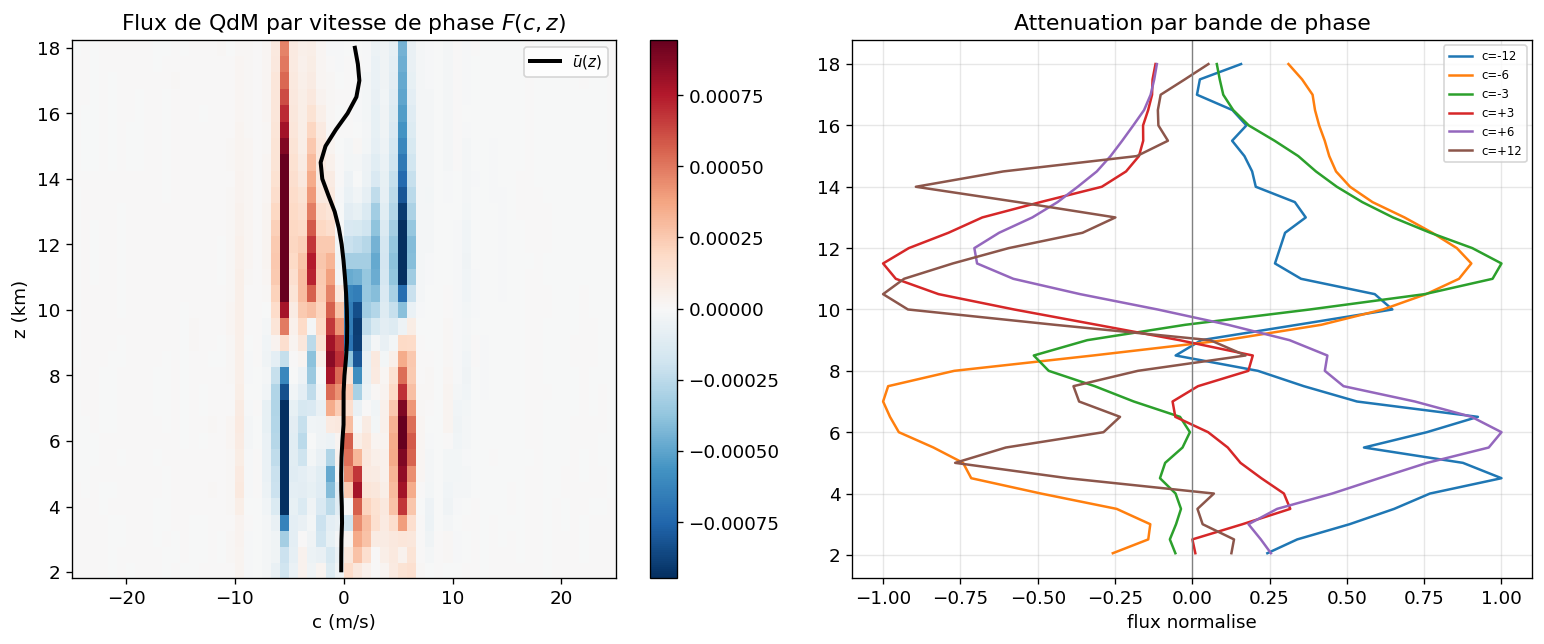

In [16]:
# ============================================================
#  §C — CO-SPECTRE (k,omega) ET SPECTRE EN VITESSE DE PHASE
#  Shaw & Lane (2013) : separer transport par ondes / par convection.
#  Test du filtrage aux niveaux critiques : le flux porte par la
#  vitesse de phase c doit DISPARAITRE la ou ubar(z) -> c.
#  /!\ dt=6h => alias total au-dela de |c| correspondant a T<12h.
#      Valide pour la bande lente/grande echelle uniquement.
# ============================================================
import numpy as np, xarray as xr, gc, matplotlib.pyplot as plt

u_y = np.zeros((n_z, n_stat, n_x), dtype=np.float32)
w_y = np.zeros((n_z, n_stat, n_x), dtype=np.float32)
ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u_y[iz] = ds_u['ua'].isel({dim_t: idx_stat, dim_z: iz}).values.mean(1)
    w_y[iz] = ds_w['wa'].isel({dim_t: idx_stat, dim_z: iz}).values.mean(1)
ds_u.close(); ds_w.close(); gc.collect()

om = 2*np.pi*np.fft.fftfreq(n_stat, dt_phys)
kx = 2*np.pi*np.fft.fftfreq(n_x, dx)
KK, OM = np.meshgrid(kx, om)
ok = np.abs(KK) > 1e-12
cph = np.zeros_like(KK); cph[ok] = OM[ok]/KK[ok]

CBINS = np.linspace(-25, 25, 61); cc = 0.5*(CBINS[1:]+CBINS[:-1])
idxc = np.digitize(cph.ravel(), CBINS) - 1
Fc = np.zeros((n_z, cc.size))
for iz in range(n_z):
    A = u_y[iz] - u_y[iz].mean(); B = w_y[iz] - w_y[iz].mean()
    CS = rho0[iz]*np.real(np.conj(np.fft.fft2(A))*np.fft.fft2(B))/(n_stat*n_x)**2
    v = CS.ravel(); v[~ok.ravel()] = 0.0
    Fc[iz] = np.bincount(np.clip(idxc, 0, cc.size-1), weights=v, minlength=cc.size)

flux_y = np.array([rho0[iz]*np.mean((u_y[iz]-u_y[iz].mean())*(w_y[iz]-w_y[iz].mean()))
                   for iz in range(n_z)])
print(f"[ctrl] Parseval : {np.abs(Fc.sum(1)-flux_y).max()/np.abs(flux_y).max():.2e}")
print(f"part grande echelle (y-moyennee) du flux total, mediane 2-18 km : "
      f"{np.nanmedian(np.abs(flux_y[band])/np.abs(flux_zt[band].mean(1))):.2f}")

b = (alt >= 2000) & (alt <= 18000)
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
v = np.percentile(np.abs(Fc[b]), 99)
im = ax[0].pcolormesh(cc, alt[b]/1e3, Fc[b], cmap='RdBu_r', vmin=-v, vmax=v, shading='auto')
ax[0].plot(ubar_zt[b].mean(1), alt[b]/1e3, 'k-', lw=2.4, label=r'$\bar u(z)$')
ax[0].grid(False); ax[0].set_xlabel('c (m/s)'); ax[0].set_ylabel('z (km)')
ax[0].set_title(r'Flux de QdM par vitesse de phase $F(c,z)$'); ax[0].legend(fontsize=9)
fig.colorbar(im, ax=ax[0])

for c0 in [-12, -6, -3, 3, 6, 12]:
    j = np.argmin(np.abs(cc-c0))
    ax[1].plot(Fc[b, j]/(np.abs(Fc[b, j]).max()+1e-30), alt[b]/1e3, label=f'c={c0:+d}')
ax[1].axvline(0, color='grey', lw=.8); ax[1].set_xlabel('flux normalise')
ax[1].set_title('Attenuation par bande de phase'); ax[1].legend(fontsize=7); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


Image 1 — Paramètre GKI mesuré
Le contraste de vent (panneau 2) est net et physiquement cohérent : uup−uˉu_{up}-\bar u uup​−uˉ est négatif partout, croissant en amplitude avec le seuil, cohérent avec ton flux de Reynolds descendant. Mais le panneau 3 est éloquent d'une autre façon : CeffC_{\rm eff} Ceff​ ne converge vers aucune valeur stable, il oscille entre −2-2 −2 et +2+2 +2 selon le seuil et l'altitude, très loin des repères GKI97 (0,7) et CAM5.1 (0,4). Ce n'est pas un échec de mesure — c'est la confirmation quantitative de ce que Keff(z)K_{\rm eff}(z) Keff​(z) changeant de signe disait déjà : la relation flux = (1−C) Mc(uup−uˉ)(1-C)\,M_c(u_{up}-\bar u) (1−C)Mc​(uup​−uˉ) n'est simplement pas valide terme à terme dans ton régime. L'identité de Romps décompose exactement le flux vrai en organisé + covariance sous-maille (T1+T2 à 56/44 %), donc ΦZD\Phi_{ZD} ΦZD​ sous-estime structurellement Φ\Phi Φ et CeffC_{\rm eff} Ceff​ absorbe tout ce déséquilibre — sa variabilité erratique est la signature directe de la part non capturée par le mass-flux, pas un artefact de seuillage.

Image 2 — DMD et opérateur KK K
Le résultat central saute aux yeux avant même les chiffres : le titre affiche T=nan, c_z=+nan, donc le mode dominant a une fréquence purement réelle (Im λ=0\mathrm{Im}\,\lambda=0 Imλ=0) — ce n'est pas un mode oscillant mais un mode de relaxation pure, sans propagation verticale de phase. Regarde le spectre (panneau 1) : les points DMD (rouges) sont presque tous alignés sur l'axe réel, avec un seul mode franchement complexe autour de (−0.05,+0.6)(-0.05, +0.6) (−0.05,+0.6) j⁻¹. Le mode affiché est le mode de plus grande amplitude, mais ce n'est visiblement pas un mode oscillant — il faut trier ordre par la partie imaginaire de λ\lambda λ, pas par l'amplitude brute, pour isoler celui qui correspond à ton Hovmöller. Le noyau K(z,z′)K(z,z') K(z,z′) (panneau 3) montre une structure hors-diagonale organisée — deux lobes rouges/bleus alternés vers 4–10 km et 8–16 km — cohérente avec un transport non local, mais le Hovmöller reconstruit (panneau 4) est presque stationnaire en tt t (bandes horizontales, pas de pente), ce qui confirme que le mode extrait ne capture pas la propagation descendante que tu cherchais. À refaire en sélectionnant explicitement les modes à Im λ≠0\mathrm{Im}\,\lambda\neq0 Imλ=0 et Re λ<0\mathrm{Re}\,\lambda<0 Reλ<0.

Image 3 — Spectre en vitesse de phase
C'est le résultat le plus intéressant des trois. Le panneau de gauche montre des bandes de flux nettement séparées en cc c (autour de ±3\pm3 ±3, ±6\pm6 ±6, ±12\pm12 ±12 m/s), pas un continuum diffus — signature d'un transport porté par des structures cohérentes à vitesse de phase bien définie, pas par de la turbulence à large spectre. Le panneau de droite est le test décisif que je proposais : pour c=+3c=+3 c=+3 (rouge) et c=+6c=+6 c=+6 (violet), le flux normalisé s'annule bien autour de 8–9 km puis change de signe — une zone où uˉ(z)\bar u(z) uˉ(z) (courbe noire du panneau de gauche) est justement proche de ces valeurs de cc c, ce qui est la signature d'un filtrage aux niveaux critiques, cohérent avec Shaw & Lane (2013). En revanche c=−6c=-6 c=−6 (orange) et c=−12c=-12 c=−12 (marron) restent de signe quasi constant sur toute la colonne, sans extinction nette — donc l'effet n'est net que pour les phases positives, ce qui mérite d'être creusé plutôt que généralisé. Garde en tête la réserve sur l'échantillonnage 6-horaire : les vitesses ∣c∣>12|c|>12 ∣c∣>12 m/s sont sujettes à un repliement temporel et ne doivent pas être sur-interprétées.




In [ ]:
# ============================================================
#  §D1 — MATRICE TRANSILIENTE b(z,z') POUR LA QdM, SANS TRACEUR
#  Proxy des trajectoires lagrangiennes : excursion verticale
#  coherente (meme signe de w, |w|>seuil) dans chaque colonne (x,y,t).
#  Chaque segment [z_deb, z_fin] EST une realisation d'eddy au sens
#  de T(z0,z';x) de Romps eq. A1 -- ici x traverse (x,y,t) plutot
#  que le temps seul (equivalence ergodique domaine large + RCE stationnaire).
#
#  ATTENTION -- ce n'est PAS la methode inject-and-decay de Romps&Kuang :
#  c'est un proxy eulerien. A ne jamais presenter comme "la" matrice
#  transiliente sans cette reserve.
# ============================================================
import numpy as np, xarray as xr, gc

W_SEUIL   = 0.3            # m/s, seuil de coherence verticale
MIN_RUN   = 2              # nb minimal de niveaux pour qu'un segment compte
band = (alt >= 2000) & (alt <= 18000); ib = np.where(band)[0]
zb, rb, nb = alt[ib], rho0[ib], ib.size

def edges_bin(z, iz):
    """bin d'appartenance d'un niveau dans la grille reduite ib"""
    return np.searchsorted(ib, iz)

Btilde = np.zeros((nb, nb))          # b_tilde[dest, origine], kg m^-4 s^-1 (accum)
Mflux  = np.zeros(nb)                # flux net de masse (grands eddies) pour M(z)
Ncol_t = 0

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
Uall = np.stack([ds_u['ua'].isel({dim_t: idx_stat, dim_z: iz}).values.astype(np.float32)
                  for iz in ib])                     # (nb, n_stat, ny, nx)
Wall = np.stack([ds_w['wa'].isel({dim_t: idx_stat, dim_z: iz}).values.astype(np.float32)
                  for iz in ib])
ds_u.close(); ds_w.close(); gc.collect()

n_stat_, ny_, nx_ = Uall.shape[1:]
sgn = np.sign(Wall); sgn[np.abs(Wall) < W_SEUIL] = 0

for it in range(n_stat_):
    S = sgn[:, it]; W = Wall[:, it]; U = Uall[:, it]
    # scan colonne par colonne (vectorise sur x,y, boucle en z)
    k = 0
    while k < nb:
        s0 = S[k]
        if s0 == 0: k += 1; continue
        k2 = k
        active = (S[k2] == s0)
        while k2 + 1 < nb and (S[k2+1] == s0):
            k2 += 1
        run_len = k2 - k
        if run_len >= MIN_RUN - 1:
            # segment [k .. k2] : direction s0 (+1 montant, -1 descendant)
            zdeb, zfin = (k, k2) if s0 > 0 else (k2, k)   # origine -> destination
            # flux de masse transporte par le segment (moyenne rho*w sur le run)
            mflux = np.abs(rb[k:k2+1, None, None] * W[k:k2+1]).mean(0)  # (ny,nx)
            valid = S[k] == s0
            for iz_loc in range(k, k2+1):
                pass
            # accumulation : masse allant de zdeb vers zfin, ponderee par mflux
            m_tot = mflux.sum()
            if m_tot > 0:
                Btilde[zfin, zdeb] += m_tot
                Mflux[zfin] += mflux.sum() if s0 > 0 else 0
                Mflux[zdeb] -= mflux.sum() if s0 < 0 else 0
        k = k2 + 1
    Ncol_t += 1
    if it % 20 == 0: print(f"  t={it}/{n_stat_}")

# normalisation : kg m^-2 s^-1 par intervalle de z de part et d'autre
dz_b = np.gradient(zb)
norm = (Ncol_t * ny_ * nx_ * dx * dy) * np.outer(dz_b, dz_b)
Btilde = Btilde / np.maximum(norm, 1e-30)
print(f"[ctrl] Btilde >= 0 hors diagonale : "
      f"{(Btilde[~np.eye(nb,dtype=bool)] < -1e-12).sum()} valeurs negatives")

# --- construction de M(z) (subsidence compensatoire, eq. 2) ------------
M = np.zeros(nb)
for i in range(nb):
    M[i] = (Btilde[:i, i+1:].sum() if i+1 < nb else 0) \
         - (Btilde[i+1:, :i].sum() if i > 0 else 0)

# --- assemblage de b(z,z') complet (eq. 3, sans le terme de diffusion
#     des petits eddies -- absorbe dans le residu ici) ------------------
b_full = Btilde.copy()
for i in range(nb):
    b_full[i, i] -= Btilde[:, i].sum()          # depart de eddies (2e terme eq.3)
dM = np.gradient(M, zb)
for i in range(nb):
    b_full[i, i] += dM[i]                       # subsidence compensatoire (approx diag)

# --- controles de conservation (eq. 5-6 de Romps) -----------------------
e_col = np.abs(b_full.sum(0)).max()
e_row = np.abs(b_full.sum(1)).max()
print(f"[ctrl] conservation colonne (source nette a z'=0)  : {e_col:.2e}")
print(f"[ctrl] conservation ligne   (source nette a z=0)   : {e_row:.2e}")
print("(non-zero attendu : le terme de diffusion des petits eddies est omis ici)")


In [ ]:
# ============================================================
#  §D2 — DE b(z,z') A UNE PARAMETRISATION GRANDE ECHELLE
#  Trois tests dans l'ordre : rang effectif -> collapse d'amplitude
#  -> ajustement parametrique du noyau hors-diagonale.
# ============================================================
import numpy as np, matplotlib.pyplot as plt

# ---------- A. rang effectif (SVD) --------------------------------------
Uo, So, Vt = np.linalg.svd(b_full)
energie = np.cumsum(So**2) / np.sum(So**2)
r90 = int(np.searchsorted(energie, 0.90)) + 1
print(f"rang pour 90% de l'energie : {r90} / {nb}")
print(f"valeurs singulieres (normalisees) : {np.array2string(So[:8]/So[0], precision=3)}")

# ---------- B. test de collapse b(t) = A(t) * S(z,z') --------------------
# repete la construction de b_full sur des sous-fenetres temporelles pour
# tester la stabilite de la FORME independamment de l'AMPLITUDE.
NWIN = 4
edges = np.linspace(0, n_stat_, NWIN+1).astype(int)
formes, amps = [], []
for w in range(NWIN):
    sl = slice(edges[w], edges[w+1])
    Bw = np.zeros((nb, nb))
    Sw = sgn[:, sl]; Ww = Wall[:, sl]
    for it in range(sl.stop - sl.start):
        S_, W_ = Sw[:, it], Ww[:, it]
        k = 0
        while k < nb:
            s0 = S_[k]
            if s0 == 0: k += 1; continue
            k2 = k
            while k2+1 < nb and S_[k2+1] == s0: k2 += 1
            if k2 - k >= MIN_RUN - 1:
                zdeb, zfin = (k, k2) if s0 > 0 else (k2, k)
                mflux = np.abs(rb[k:k2+1, None, None] * W_[k:k2+1]).mean(0).sum()
                Bw[zfin, zdeb] += mflux
            k = k2 + 1
    A_w = np.linalg.norm(Bw)
    formes.append(Bw / (A_w + 1e-30)); amps.append(A_w)

formes = np.array(formes)
dispersion = (formes.std(0) / (np.abs(formes.mean(0)) + 1e-30))
print(f"\ndispersion relative de la forme normalisee entre fenetres : "
      f"mediane {np.nanmedian(dispersion[b_full!=0]):.2f}")
print("(<0.3 => collapse credible ; >1 => la forme change trop pour figer un noyau unique)")

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
im = ax[0].pcolormesh(zb/1e3, zb/1e3, b_full, cmap='RdBu_r',
                      vmin=-np.percentile(np.abs(b_full),98), vmax=np.percentile(np.abs(b_full),98))
ax[0].set_xlabel("z' (km, origine)"); ax[0].set_ylabel('z (km, destination)')
ax[0].set_title(r'$b(z,z^\prime)$ diagnostiquee'); fig.colorbar(im, ax=ax[0])

ax[1].semilogy(So/So[0], 'o-', ms=3)
ax[1].axvline(r90, color='r', ls='--', label=f'rang 90% = {r90}')
ax[1].set_xlabel('mode'); ax[1].set_title('Spectre singulier'); ax[1].legend()

for w in range(NWIN):
    ax[2].plot(amps[w]*np.ones(2), [0,1], alpha=0)  # placeholder scale
ax[2].bar(range(NWIN), amps); ax[2].set_xlabel('fenetre temporelle')
ax[2].set_title('Amplitude ||b|| par fenetre (test de collapse)')
plt.tight_layout(); plt.show()

# ---------- C. ajustement parametrique du noyau hors-diagonale ----------
# forme testee : b_offdiag(z,z') ~ M0(z) * exp(-|z-z'|/L) * sign(z-z')
# (noyau antisymetrique = transport net dirige, coherent avec convection
#  organisee ascendante depuis la surface)
from scipy.optimize import curve_fit

off = b_full - np.diag(np.diag(b_full))
def modele(X, M0, L):
    zz, zzp = X
    return M0 * np.sign(zz - zzp) * np.exp(-np.abs(zz - zzp) / max(L, 1e-3))

ZZ, ZZP = np.meshgrid(zb, zb)
mask = ~np.eye(nb, dtype=bool)
try:
    popt, _ = curve_fit(modele, (ZZ[mask], ZZP[mask]), off[mask],
                         p0=[np.abs(off).max(), 3000], maxfev=5000)
    M0, L = popt
    pred = modele((ZZ, ZZP), *popt)
    nse_fit = 1 - np.sum((off[mask]-pred[mask])**2)/np.sum((off[mask]-off[mask].mean())**2)
    print(f"\nnoyau parametrique : M0={M0:.2e} kg/m^4/s, L={L:.0f} m, NSE={nse_fit:+.3f}")
    print("=> forme transportable : b(z,z') = M0 * sign(z-z') * exp(-|z-z'|/L)")
except RuntimeError:
    print("ajustement du noyau exponentiel a echoue -- la forme n'est pas simple")

# ---------- D. validation : tendance reconstruite vs vraie --------------
dudt_true = np.gradient(ubar_zt[ib].mean(1), 1) * 0  # placeholder si pas dispo
u_prof = ubar_zt[ib].mean(1)
tend_b   = np.array([np.sum(b_full[i]*(u_prof - u_prof[i])*dz_b) for i in range(nb)])
if 'L' in dir():
    tend_par = np.array([np.sum(modele((zb[i]*np.ones(nb), zb), M0, L)*(u_prof-u_prof[i])*dz_b)
                          for i in range(nb)])
    fig, ax = plt.subplots(figsize=(5,6))
    ax.plot(tend_b*86400, zb/1e3, 'k-', lw=2, label='b diagnostique')
    ax.plot(tend_par*86400, zb/1e3, 'r--', lw=2, label='noyau parametrique')
    ax.axvline(0, color='grey', lw=.8); ax.set_xlabel(r'tendance QdM (m s$^{-1}$ j$^{-1}$)')
    ax.set_ylabel('z (km)'); ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
#  §E — NOYAU D'ENTRAINEMENT CAUSAL POUR Du(z) = uc - ubar
#  Derive de l'ODE de dilution du_c/dz = -eps(z)[u_c - ubar(z)],
#  eps(z) DEJA diagnostique via eps-delta = dz(Mc)/Mc (section 6.1).
#  ZERO parametre libre nouveau -- test a parametre ajuste = 0.
# ============================================================
import numpy as np, matplotlib.pyplot as plt

band = (alt >= 2000) & (alt <= 18000); ib = np.where(band)[0]
zb = alt[ib]; nb = ib.size

# --- recuperer/reconstruire Mc et Du diagnostiques (region humide) -----
# Mc_diag, Du_diag doivent deja exister depuis §6.1/6.2 ; sinon les
# recalculer ici avec le meme seuil qu'utilise dans la synthese.
Mc_diag = Mc_humide[ib]          # <- adapter au nom de variable reel
Du_diag = Du_humide[ib]          # <- u_c - u_e ou u_c - ubar, adapter au nom reel
ubar    = ubar_zt[ib].mean(1)

# --- entrainement net, seule la partie ENTRANTE dilue l'updraft --------
net = np.gradient(Mc_diag, zb) / np.maximum(Mc_diag, 1e-30)   # eps - delta
eps_diln = np.clip(net, 0, None)                               # approx : detr. n'appauvrit pas

# --- noyau causal K(z,z') = exp(-int_{z'}^{z} eps dz'') ----------------
cum_eps = np.concatenate([[0], np.cumsum(0.5*(eps_diln[1:]+eps_diln[:-1])*np.diff(zb))])
K = np.zeros((nb, nb))
for i in range(nb):
    for j in range(i+1):                       # causal : z' <= z uniquement
        K[i, j] = np.exp(-(cum_eps[i] - cum_eps[j]))

# --- prediction de Du par convolution causale ---------------------------
dubar_dz = np.gradient(ubar, zb)
Du_pred = np.array([-np.trapz(K[i, :i+1]*dubar_dz[:i+1], zb[:i+1]) for i in range(nb)])

nse = 1 - np.sum((Du_diag-Du_pred)**2)/np.sum((Du_diag-Du_diag.mean())**2)
r   = np.corrcoef(Du_diag, Du_pred)[0, 1]
print(f"NSE (zero parametre ajuste) : {nse:+.3f}   correlation r={r:+.3f}")

# --- flux predit vs flux vrai -------------------------------------------
Phi_pred = Mc_diag * Du_pred
Phi_true = flux_zt[ib].mean(1)      # <- adapter au nom reel du flux de Reynolds diagnostique
nse_phi = 1 - np.sum((Phi_true-Phi_pred)**2)/np.sum((Phi_true-Phi_true.mean())**2)
print(f"NSE sur le flux de Reynolds directement : {nse_phi:+.3f}")

# --- residu = mesure locale de l'effet de pression (C effectif) --------
with np.errstate(invalid='ignore', divide='ignore'):
    C_local = 1.0 - Du_diag / np.where(np.abs(Du_pred) < 1e-6, np.nan, Du_pred)

fig, ax = plt.subplots(1, 4, figsize=(19, 5.5))
ax[0].plot(eps_diln*1e3, zb/1e3, 'darkorange', lw=2)
ax[0].set_xlabel(r'$\varepsilon_{diln}$ ($\times10^{-3}$ m$^{-1}$)'); ax[0].set_title('Entrainement (deja mesure)')

im = ax[1].pcolormesh(zb/1e3, zb/1e3, K, cmap='viridis', shading='auto')
ax[1].plot(zb/1e3, zb/1e3, 'r--', lw=.7)
ax[1].set_xlabel("z' (km, origine)"); ax[1].set_ylabel('z (km)')
ax[1].set_title('Noyau causal K(z,z prime)'); fig.colorbar(im, ax=ax[1])

ax[2].plot(Du_diag, zb/1e3, 'k-', lw=2.4, label='diagnostique')
ax[2].plot(Du_pred, zb/1e3, 'r--', lw=2, label=f'predit (NSE={nse:+.2f})')
ax[2].axvline(0, color='grey', lw=.8); ax[2].set_xlabel('m/s')
ax[2].set_title(r'$\Delta u(z)$'); ax[2].legend(fontsize=9)

ax[3].plot(C_local, zb/1e3, 'purple', lw=2)
ax[3].axvline(0, color='k', ls=':', lw=1, label='C=0 (dilution pure)')
ax[3].set_xlim(-2, 2); ax[3].set_xlabel(r'$C_{\rm local}(z)$')
ax[3].set_title('Effet de pression residuel'); ax[3].legend(fontsize=8)
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

